In [ ]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u, constants as const
from astropy.cosmology import Planck18 as cosmo

from scipy.ndimage import map_coordinates
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import curve_fit
from scipy.stats import chi2

try:
    plt.style.use('/Users/zijianzhang/Astro_Data/paper.mplstyle')
except Exception:
    pass

ROOT = Path('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211')
CODE = ROOT / 'code'
CHEMA_DIR = ROOT / 'lensing_model' / 'Chema_model'
JOSEPH_DIR = ROOT / 'lensing_model' / 'Joseph_model'
JOSEPH_SOURCE_FILE = JOSEPH_DIR / 'R2211_sources_1.csv'
JOSEPH_TD_FILE = JOSEPH_DIR / 'R2211_TD_Sys9-10.csv'
OGURI_FILE = ROOT / 'lensing_model' / 'Oguri_model' / 'rj2211_glafic_v0p9_summary_mu_td_lrds.dat'
OGURI_JAFFE_FILE = ROOT / 'lensing_model' / 'Oguri_model' / 'rj2211_glafic_v0p9_summary_mu_td_lrds_jaffe.dat'
PHOT_FILE = ROOT / 'catalog' / 'venus_slice_hst_combine_lenslrd_phot.fits'
COORD_FILE = ROOT / 'catalog' / 'lens_lrd_coords.fits'

Z_LENS = 0.396
Z_MAP = 3.0
Z_SRC = 4.3
SOURCE_ID = '1'      # photometric system label in ID_2, i.e. 1.1--1.4
OGURI_SOURCE_ID = '9' # corresponding Oguri/glafic source id in the fiducial file
MU_FLOOR_FRAC = 0.10

OUTDIR = CODE / 'lensmodel_systematic'
OUTDIR.mkdir(exist_ok=True)

print('Chema directory:', CHEMA_DIR)
print('Joseph directory:', JOSEPH_DIR)
print('Output directory:', OUTDIR)

Duplicate key in file '/Users/zijianzhang/Astro_Data/paper.mplstyle', line 23 ('axes.linewidth : 1.5')


Chema directory: /Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/Chema_model
Joseph directory: /Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/Joseph_model
Output directory: /Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/code/referee_Chema_lensmodel_outputs


## Helper functions

In [25]:
def distance_ratio(z_lens, z_source):
    """Return D_ls / D_s for angular-diameter distances."""
    return (cosmo.angular_diameter_distance_z1z2(z_lens, z_source) /
            cosmo.angular_diameter_distance(z_source)).decompose().value


def lensing_rescale_factor(z_lens=Z_LENS, z_from=Z_MAP, z_to=Z_SRC):
    """Scale alpha/kappa/gamma from z_from to z_to."""
    return distance_ratio(z_lens, z_to) / distance_ratio(z_lens, z_from)


ARCSEC_TO_RAD = (1 * u.arcsec).to(u.rad).value
TIME_DELAY_COEFF_DAY_PER_ARCSEC2 = (
    ((1 + Z_LENS) *
     cosmo.angular_diameter_distance(Z_LENS) *
     cosmo.angular_diameter_distance(Z_SRC) /
     cosmo.angular_diameter_distance_z1z2(Z_LENS, Z_SRC) /
     const.c).to(u.day).value * ARCSEC_TO_RAD**2
)

print('Dds/Ds scale z=3 -> z=%.2f: %.5f' % (Z_SRC, lensing_rescale_factor()))
print('Time-delay coefficient: %.3f day / arcsec^2' % TIME_DELAY_COEFF_DAY_PER_ARCSEC2)


def read_oguri_lens_data(filename):
    """Parse Oguri/glafic summary files with x, y, mu, dt and asymmetric errors."""
    data = {}
    pattern = re.compile(
        r'(?P<param>[xy]|mu|dt)\((?P<id>[\d\.]+)\).*?'
        r'(?P<value>[-\d\.]+)\^\{\+(?P<errp>[\d\.]+)\}_\{\-(?P<errm>[\d\.]+)\}'
    )
    with open(filename, 'r') as f:
        for line in f:
            m = pattern.search(line.strip())
            if m is None:
                continue
            img_id = m.group('id')
            param = m.group('param')
            data.setdefault(img_id, {})[param] = (
                float(m.group('value')),
                float(m.group('errp')),
                float(m.group('errm')),
            )
    return data


def phot_id_to_oguri_id(phot_id, oguri_source_id=OGURI_SOURCE_ID):
    """Match the image-label convention used in the original notebooks.

    In the original light-curve notebook, photometric images 1.3 and 1.4 are
    swapped when querying Oguri ids 9.4 and 9.3, respectively.  The same rule
    is used here for a like-for-like comparison.
    """
    img = int(str(phot_id).split('.')[1])
    if img == 3:
        img = 4
    elif img == 4:
        img = 3
    return f'{oguri_source_id}.{img}'


def symmetric_err(value_tuple):
    """Use the larger asymmetric error as a symmetric uncertainty."""
    return max(abs(value_tuple[1]), abs(value_tuple[2]))


oguri = read_oguri_lens_data(OGURI_FILE)
oguri_jaffe = read_oguri_lens_data(OGURI_JAFFE_FILE)
print('Parsed Oguri entries:', len(oguri))
print('Parsed Oguri pseudo-Jaffe entries:', len(oguri_jaffe))

Dds/Ds scale z=3 -> z=4.30: 1.04409
Time-delay coefficient: 56.243 day / arcsec^2
Parsed Oguri entries: 15
Parsed Oguri pseudo-Jaffe entries: 15


In [26]:
class ChemaModel:
    """Thin reader/calculator for one Chema/Diego model case."""

    def __init__(self, case, base_dir=CHEMA_DIR, z_lens=Z_LENS, z_map=Z_MAP, z_source=Z_SRC):
        self.case = int(case)
        self.base_dir = Path(base_dir)
        self.z_lens = z_lens
        self.z_map = z_map
        self.z_source = z_source
        self.scale = lensing_rescale_factor(z_lens, z_map, z_source)
        self.paths = {
            'alphax': self.base_dir / f'AlphaX_Z3_arcsec_RJ2211_Case{case}.fits',
            'alphay': self.base_dir / f'AlphaY_Z3_arcsec_RJ2211_Case{case}.fits',
            'kappa': self.base_dir / f'Kappa_Z3_RJ2211_Case{case}.fits',
            'gamma': self.base_dir / f'Gamma_Z3_RJ2211_Case{case}.fits',
            'mu_z3': self.base_dir / f'Magnification_Z3_RJ2211_Case{case}.fits',
        }
        self._hdus = {}
        self.header = fits.getheader(self.paths['alphax'])
        self.wcs = WCS(self.header)
        self.ra0 = self.header['CRVAL1']
        self.dec0 = self.header['CRVAL2']
        self.pixscale_arcsec = abs(self.header.get('CDELT1', self.header.get('CD1_1'))) * 3600

    def hdu(self, key):
        if key not in self._hdus:
            self._hdus[key] = fits.open(self.paths[key], memmap=True)[0]
        return self._hdus[key]

    def xy_from_radec(self, ra_deg, dec_deg):
        """Return lens-plane offsets in Chema/glafic-like arcsec coordinates.

        Because CDELT1 is negative, x is west-positive: x = -(RA-RA0) cos(dec0).
        This matches the Oguri x/y signs and gives compact source-plane beta scatter.
        """
        ra = np.asarray(ra_deg, dtype=float)
        dec = np.asarray(dec_deg, dtype=float)
        x = -(ra - self.ra0) * np.cos(np.deg2rad(self.dec0)) * 3600
        y = (dec - self.dec0) * 3600
        return x, y

    def pixel_from_radec(self, ra_deg, dec_deg):
        coords = SkyCoord(np.asarray(ra_deg, dtype=float) * u.deg,
                          np.asarray(dec_deg, dtype=float) * u.deg)
        return self.wcs.world_to_pixel(coords)

    def interp_map(self, key, ra_deg, dec_deg, order=1):
        xpix, ypix = self.pixel_from_radec(ra_deg, dec_deg)
        data = self.hdu(key).data
        return map_coordinates(data, [ypix, xpix], order=order, mode='nearest')

    def alpha(self, ra_deg, dec_deg):
        ax = self.interp_map('alphax', ra_deg, dec_deg) * self.scale
        ay = self.interp_map('alphay', ra_deg, dec_deg) * self.scale
        return ax, ay

    def kappa_gamma_mu(self, ra_deg, dec_deg):
        kappa = self.interp_map('kappa', ra_deg, dec_deg) * self.scale
        gamma = self.interp_map('gamma', ra_deg, dec_deg) * self.scale
        mu = 1.0 / ((1.0 - kappa)**2 - gamma**2)
        mu_z3_file = self.interp_map('mu_z3', ra_deg, dec_deg)
        return kappa, gamma, mu, mu_z3_file

    def beta_positions(self, ra_deg, dec_deg):
        x, y = self.xy_from_radec(ra_deg, dec_deg)
        ax, ay = self.alpha(ra_deg, dec_deg)
        return np.column_stack([x - ax, y - ay])

    def _alpha_interpolators_for_xy(self, x, y, margin_arcsec=12):
        """Build alpha interpolators on a small crop enclosing all requested points."""
        ax_hdu = self.hdu('alphax')
        ay_hdu = self.hdu('alphay')
        ny, nx = ax_hdu.data.shape
        x_axis = (np.arange(nx) - (self.header['CRPIX1'] - 1)) * self.pixscale_arcsec
        y_axis = (np.arange(ny) - (self.header['CRPIX2'] - 1)) * self.pixscale_arcsec

        ix = np.where((x_axis >= np.min(x) - margin_arcsec) &
                      (x_axis <= np.max(x) + margin_arcsec))[0]
        iy = np.where((y_axis >= np.min(y) - margin_arcsec) &
                      (y_axis <= np.max(y) + margin_arcsec))[0]
        if len(ix) == 0 or len(iy) == 0:
            raise RuntimeError('Requested image positions fall outside Chema alpha maps.')

        ax_crop = ax_hdu.data[iy.min():iy.max()+1, ix.min():ix.max()+1] * self.scale
        ay_crop = ay_hdu.data[iy.min():iy.max()+1, ix.min():ix.max()+1] * self.scale
        sub_y = y_axis[iy.min():iy.max()+1]
        sub_x = x_axis[ix.min():ix.max()+1]
        interp_ax = RegularGridInterpolator((sub_y, sub_x), ax_crop, bounds_error=False, fill_value=None)
        interp_ay = RegularGridInterpolator((sub_y, sub_x), ay_crop, bounds_error=False, fill_value=None)
        return interp_ax, interp_ay

    def relative_time_delays(self, ra_deg, dec_deg, beta='mean', n_per_arcsec=20):
        """Compute relative delays in days from the Fermat potential.

        psi differences are estimated as integral alpha dot dtheta along a straight
        path from image 0 to each image.  The absolute delay zero-point is then
        shifted to the first-arriving image.
        """
        x, y = self.xy_from_radec(ra_deg, dec_deg)
        interp_ax, interp_ay = self._alpha_interpolators_for_xy(x, y)
        pts = np.column_stack([y, x])
        ax = interp_ax(pts)
        ay = interp_ay(pts)
        beta_i = np.column_stack([x - ax, y - ay])
        if isinstance(beta, str) and beta == 'mean':
            beta_xy = np.nanmean(beta_i, axis=0)
        else:
            beta_xy = np.asarray(beta, dtype=float)

        x0, y0 = x[0], y[0]
        psi = np.zeros(len(x), dtype=float)
        for i in range(1, len(x)):
            dist = np.hypot(x[i] - x0, y[i] - y0)
            n = max(200, int(np.ceil(dist * n_per_arcsec)))
            xs = np.linspace(x0, x[i], n)
            ys = np.linspace(y0, y[i], n)
            axs = interp_ax(np.column_stack([ys, xs]))
            ays = interp_ay(np.column_stack([ys, xs]))
            dx = (x[i] - x0) / (n - 1)
            dy = (y[i] - y0) / (n - 1)
            psi[i] = np.trapz(axs * dx + ays * dy)

        tau = 0.5 * ((x - beta_xy[0])**2 + (y - beta_xy[1])**2) - psi
        delay_days = (tau - np.nanmin(tau)) * TIME_DELAY_COEFF_DAY_PER_ARCSEC2
        return delay_days, tau, psi, beta_xy, beta_i



def chema_values_at_xy(case, xy_records_by_system, beta_exclude=None, model_label=None):
    """Evaluate a Chema/Diego model at supplied Oguri-model x/y positions.

    xy_records_by_system maps system names to records whose first three fields
    are image_id, x_arcsec, y_arcsec. Relative delays are computed within each
    system and shifted so the first-arriving image has Delta t = 0.
    """
    model = ChemaModel(case)
    hdr = model.header
    ny, nx = model.hdu('kappa').data.shape
    x_axis = (np.arange(nx) - (hdr['CRPIX1'] - 1)) * model.pixscale_arcsec
    y_axis = (np.arange(ny) - (hdr['CRPIX2'] - 1)) * model.pixscale_arcsec

    def interp_xy(key, x, y):
        data = model.hdu(key).data
        interp = RegularGridInterpolator((y_axis, x_axis), data, bounds_error=False, fill_value=np.nan)
        return interp(np.column_stack([np.asarray(y, dtype=float), np.asarray(x, dtype=float)]))

    out = []
    for system, records in xy_records_by_system.items():
        image_ids = [str(rec[0]) for rec in records]
        x_arr = np.array([rec[1] for rec in records], dtype=float)
        y_arr = np.array([rec[2] for rec in records], dtype=float)

        kappa = interp_xy('kappa', x_arr, y_arr) * model.scale
        gamma = interp_xy('gamma', x_arr, y_arr) * model.scale
        mu = 1.0 / ((1.0 - kappa)**2 - gamma**2)
        mu_z3_file = interp_xy('mu_z3', x_arr, y_arr)

        interp_ax, interp_ay = model._alpha_interpolators_for_xy(x_arr, y_arr)
        pts = np.column_stack([y_arr, x_arr])
        ax = interp_ax(pts)
        ay = interp_ay(pts)
        beta_i = np.column_stack([x_arr - ax, y_arr - ay])
        if beta_exclude and system in beta_exclude:
            keep = np.array([img not in beta_exclude[system] for img in image_ids])
            beta_xy = np.nanmean(beta_i[keep], axis=0)
        else:
            beta_xy = np.nanmean(beta_i, axis=0)
        beta_scatter = np.sqrt(np.nanmean(np.sum((beta_i - beta_xy)**2, axis=1)))

        x0, y0 = x_arr[0], y_arr[0]
        psi = np.zeros(len(x_arr), dtype=float)
        for i in range(1, len(x_arr)):
            dist = np.hypot(x_arr[i] - x0, y_arr[i] - y0)
            n = max(200, int(np.ceil(dist * 20)))
            xs = np.linspace(x0, x_arr[i], n)
            ys = np.linspace(y0, y_arr[i], n)
            axs = interp_ax(np.column_stack([ys, xs]))
            ays = interp_ay(np.column_stack([ys, xs]))
            dx = (x_arr[i] - x0) / (n - 1)
            dy = (y_arr[i] - y0) / (n - 1)
            psi[i] = np.trapz(axs * dx + ays * dy)
        tau = 0.5 * ((x_arr - beta_xy[0])**2 + (y_arr - beta_xy[1])**2) - psi
        dt_day = (tau - np.nanmin(tau)) * TIME_DELAY_COEFF_DAY_PER_ARCSEC2

        for image_id, x, y, m, dt, bx, by, kap, gam, mu_z3 in zip(
            image_ids, x_arr, y_arr, mu, dt_day, beta_i[:, 0], beta_i[:, 1], kappa, gamma, mu_z3_file
        ):
            out.append({
                'model': model_label or f'Chema Case{case} @ Oguri NFW xy',
                'system': system,
                'image': image_id,
                'ID': image_id,
                'matched_lens_id': image_id,
                'x_arcsec': x,
                'y_arcsec': y,
                'mu': m,
                'mu_abs': abs(m),
                'mu_err_used': MU_FLOOR_FRAC * abs(m),
                'dt_day': dt,
                'dt_err_day': np.nan,
                'dt_rest_yr': dt / 365.25 / (1 + Z_SRC),
                'beta_x_arcsec': bx,
                'beta_y_arcsec': by,
                'beta_scatter_arcsec': beta_scatter,
                'kappa_zsrc': kap,
                'gamma_zsrc': gam,
                'mu_z3_file': mu_z3,
                'position_source': 'Oguri NFW model-output xy',
            })
    return pd.DataFrame(out)

# -----------------------------------------------------------------------------
# Joseph external model reader.
# -----------------------------------------------------------------------------
JOSEPH_MODEL_NAME = 'Allingham'
JOSEPH_SYSTEM_TO_PREFIX = {'RX1': '9', 'RX2': '10'}
JOSEPH_PHOT_SOURCE_TO_PREFIX = {'1': '9', '2': '10'}


def _angular_sep_arcsec(ra1, dec1, ra2, dec2):
    dra = (np.asarray(ra1, dtype=float) - np.asarray(ra2, dtype=float)) * np.cos(np.deg2rad(dec2)) * 3600.0
    ddec = (np.asarray(dec1, dtype=float) - np.asarray(dec2, dtype=float)) * 3600.0
    return np.hypot(dra, ddec)


def read_joseph_model_outputs(source_file=JOSEPH_SOURCE_FILE, td_file=JOSEPH_TD_FILE):
    """Read Joseph model CSVs and return signed mu and first-arrival-relative delays.

    The Joseph time-delay CSV stores delays in observer-frame years relative to
    one reference image in each system.  For comparison to Oguri/Chema, shift
    each system so that the first-arriving image has Delta t = 0 day.
    """
    src = pd.read_csv(source_file)
    td = pd.read_csv(td_file)
    src['Id'] = src['Id'].astype(str)
    td['Id'] = td['Id'].astype(str)
    merged = td.merge(src[['Id', 'RA', 'Dec']], on='Id', how='left')

    rows = []
    for system, prefix in JOSEPH_SYSTEM_TO_PREFIX.items():
        mask = merged['Id'].str.startswith(prefix + '.')
        sub = merged[mask].copy()
        if len(sub) == 0:
            continue
        dt0 = sub['Best_TD [yrs, observer]'].min()
        for _, row in sub.iterrows():
            local_image = str(row['Id']).split('.')[1]
            image = ('1.' if system == 'RX1' else '2.') + local_image
            # RX1 numbering follows the same sky-position convention as Oguri/glafic:
            # Joseph 9.3 is the observed 1.4 image, and Joseph 9.4 is observed 1.3.
            if system == 'RX1' and image == '1.3':
                image = '1.4'
            elif system == 'RX1' and image == '1.4':
                image = '1.3'
            mu = float(row['Best_Mu'])
            mu_err = float(row['Std_Mu']) if np.isfinite(row['Std_Mu']) else np.nan
            dt_day = (float(row['Best_TD [yrs, observer]']) - float(dt0)) * 365.25
            dt_err_day = float(row['Std_TD [yrs, observer]']) * 365.25 if np.isfinite(row['Std_TD [yrs, observer]']) else np.nan
            rows.append({
                'model': JOSEPH_MODEL_NAME,
                'system': system,
                'image': image,
                'joseph_id': str(row['Id']),
                'RA': float(row['RA']) if np.isfinite(row['RA']) else np.nan,
                'DEC': float(row['Dec']) if np.isfinite(row['Dec']) else np.nan,
                'mu': mu,
                'mu_abs': abs(mu),
                'mu_err': mu_err,
                'dt_day': dt_day,
                'dt_err_day': dt_err_day,
                'dt_rest_yr': dt_day / 365.25 / (1 + Z_SRC),
                'position_source': 'Joseph_model CSV',
            })
    out = pd.DataFrame(rows)
    return out.sort_values(['system', 'image']).reset_index(drop=True)


joseph_outputs = read_joseph_model_outputs()
print('Parsed Joseph entries:', len(joseph_outputs))
display(joseph_outputs)


Parsed Joseph entries: 9


,model,system,image,joseph_id,RA,DEC,mu,mu_abs,mu_err,dt_day,dt_err_day,dt_rest_yr,position_source
0,Allingham,RX1,1.1,9.1,332.95386,-3.83207,4.0732,4.0732,0.0152,30914.906100,0.000000,15.969887,Joseph_model CSV
1,Allingham,RX1,1.2,9.2,332.92441,-3.82768,2.4717,2.4717,0.0109,0.000000,172.069275,0.000000,Joseph_model CSV
2,Allingham,RX1,1.3,9.4,332.94436,-3.81911,-3.5368,3.5368,0.0329,46962.347475,50.879325,24.259604,Joseph_model CSV
3,Allingham,RX1,1.4,9.3,332.94059,-3.84067,-2.4480,2.4480,0.0193,44161.391325,76.227675,22.812698,Joseph_model CSV
4,Allingham,RX2,2.1,10.1,332.94047,-3.83532,-1.3715,1.3715,0.0341,58135.746750,0.000000,30.031509,Joseph_model CSV
5,Allingham,RX2,2.2,10.2,332.94092,-3.83182,2.4814,2.4814,0.3059,57570.960675,219.624825,29.739755,Joseph_model CSV
6,Allingham,RX2,2.3,10.3,332.95469,-3.82245,3.9171,3.9171,0.0266,7514.470875,201.581475,3.881792,Joseph_model CSV
7,Allingham,RX2,2.4,10.4,332.92738,-3.81977,4.2220,4.2220,0.0379,0.000000,207.608100,0.000000,Joseph_model CSV
8,Allingham,RX2,2.5,10.5,332.94432,-3.81432,-8.2839,8.2839,0.1260,13165.034475,289.497150,6.800736,Joseph_model CSV


## Load coordinates and compute lensing quantities

In [27]:
coords_all = Table.read(COORD_FILE)
coords = coords_all[[str(v).startswith(f'{SOURCE_ID}.') for v in coords_all['ID']]]
coords.sort('ID')
print(coords[['ID', 'RA', 'DEC']])

models = {
    'Oguri fiducial': None,
    'Chema Case1': ChemaModel(1),
    'Diego': ChemaModel(2),
    JOSEPH_MODEL_NAME: None,
}

rows = []
oguri_nfw_xy_source = {'RX1': []}
for row in coords:
    phot_id = str(row['ID'])
    og_id = phot_id_to_oguri_id(phot_id)
    mu = oguri[og_id]['mu'][0]
    mu_err = symmetric_err(oguri[og_id]['mu'])
    dt = oguri[og_id]['dt'][0]
    dt_err = symmetric_err(oguri[og_id]['dt'])
    rows.append({
        'ID': phot_id,
        'model': 'Oguri fiducial',
        'matched_lens_id': og_id,
        'mu': mu,
        'mu_abs': abs(mu),
        'mu_err_used': max(mu_err, MU_FLOOR_FRAC * abs(mu)),
        'dt_day': dt,
        'dt_err_day': dt_err,
        'dt_rest_yr': dt / 365.25 / (1 + Z_SRC),
        'beta_x_arcsec': np.nan,
        'beta_y_arcsec': np.nan,
        'beta_scatter_arcsec': np.nan,
        'kappa_zsrc': np.nan,
        'gamma_zsrc': np.nan,
        'mu_z3_file': np.nan,
        'position_source': 'Oguri fiducial summary',
    })
    oguri_nfw_xy_source['RX1'].append((phot_id, oguri[og_id]['x'][0], oguri[og_id]['y'][0]))

for case, label in [(1, 'Chema Case1'), (2, 'Diego')]:
    sampled = chema_values_at_xy(case, oguri_nfw_xy_source, model_label=label)
    rows.extend(sampled.to_dict('records'))

# Joseph model: use the externally supplied signed magnifications and observer-frame
# delays, shifted above to the first-arriving image in each system.  Match by the
# image labels after the RX1 1.3/1.4 sky-position convention is applied.
joseph_by_image = joseph_outputs[joseph_outputs['system'] == 'RX1'].set_index('image')
for row in coords:
    phot_id = str(row['ID'])
    if phot_id not in joseph_by_image.index:
        continue
    jj = joseph_by_image.loc[phot_id]
    sep_arcsec = _angular_sep_arcsec(jj['RA'], jj['DEC'], row['RA'], row['DEC'])
    rows.append({
        'ID': phot_id,
        'model': JOSEPH_MODEL_NAME,
        'matched_lens_id': jj['joseph_id'],
        'mu': jj['mu'],
        'mu_abs': abs(jj['mu']),
        'mu_err_used': max(jj['mu_err'], MU_FLOOR_FRAC * abs(jj['mu'])) if np.isfinite(jj['mu_err']) else MU_FLOOR_FRAC * abs(jj['mu']),
        'dt_day': jj['dt_day'],
        'dt_err_day': jj['dt_err_day'],
        'dt_rest_yr': jj['dt_rest_yr'],
        'beta_x_arcsec': np.nan,
        'beta_y_arcsec': np.nan,
        'beta_scatter_arcsec': np.nan,
        'kappa_zsrc': np.nan,
        'gamma_zsrc': np.nan,
        'mu_z3_file': np.nan,
        'position_match_sep_arcsec': sep_arcsec,
    })

lens_df = pd.DataFrame(rows)
lens_df = lens_df.sort_values(['ID', 'model']).reset_index(drop=True)
lens_df.to_csv(OUTDIR / f'lensing_comparison_source{SOURCE_ID}.csv', index=False)

with pd.option_context('display.precision', 4):
    display(lens_df)

 ID      RA        DEC    
--- ----------- ----------
1.1 332.9538544 -3.8320661
1.2 332.9244078 -3.8276834
1.3 332.9443683 -3.8191093
1.4 332.9405856  -3.840673


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


,ID,model,matched_lens_id,mu,mu_abs,mu_err_used,dt_day,dt_err_day,dt_rest_yr,beta_x_arcsec,...,beta_scatter_arcsec,kappa_zsrc,gamma_zsrc,mu_z3_file,position_source,system,image,x_arcsec,y_arcsec,position_match_sep_arcsec
0,1.1,Allingham,9.1,4.0732,4.0732,0.4073,30914.9061,0.0000,15.9699,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0245
1,1.1,Chema Case1,1.1,3.0079,3.0079,0.3008,30738.5996,NaN,15.8788,7.1870,...,0.2843,0.3385,0.3243,2.7757,Oguri NFW model-output xy,RX1,1.1,-44.83,-10.58,NaN
2,1.1,Diego,1.1,3.5637,3.5637,0.3564,31809.2385,NaN,16.4319,6.9777,...,0.2227,0.3621,0.3554,3.2176,Oguri NFW model-output xy,RX1,1.1,-44.83,-10.58,NaN
3,1.1,Oguri fiducial,9.1,3.6800,3.6800,0.3680,30055.2700,687.4800,15.5258,NaN,...,NaN,NaN,NaN,NaN,Oguri fiducial summary,NaN,NaN,NaN,NaN,NaN
4,1.2,Allingham,9.2,2.4717,2.4717,0.2472,0.0000,172.0693,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0146
5,1.2,Chema Case1,1.2,2.1010,2.1010,0.2101,0.0000,NaN,0.0000,7.2568,...,0.2843,0.2652,0.2530,2.0087,Oguri NFW model-output xy,RX1,1.2,60.48,4.79,NaN
6,1.2,Diego,1.2,2.2107,2.2107,0.2211,0.0000,NaN,0.0000,7.2162,...,0.2227,0.2684,0.2880,2.1012,Oguri NFW model-output xy,RX1,1.2,60.48,4.79,NaN
7,1.2,Oguri fiducial,9.2,2.2300,2.2300,0.2230,0.0000,0.0000,0.0000,NaN,...,NaN,NaN,NaN,NaN,Oguri fiducial summary,NaN,NaN,NaN,NaN,NaN
8,1.3,Allingham,9.4,-3.5368,3.5368,0.3537,46962.3475,50.8793,24.2596,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0299
9,1.3,Chema Case1,1.3,-3.1746,3.1746,0.3175,49269.6750,NaN,25.4515,7.2651,...,0.2843,0.9648,0.5623,-3.5170,Oguri NFW model-output xy,RX1,1.3,-10.67,35.19,NaN


In [28]:
# Compact comparison relative to Oguri for the referee discussion.
og = lens_df[lens_df['model'] == 'Oguri fiducial'].set_index('ID')
compare_rows = []
for model_name in ['Chema Case1', 'Diego', JOSEPH_MODEL_NAME]:
    mm = lens_df[lens_df['model'] == model_name].set_index('ID')
    for image_id in og.index:
        compare_rows.append({
            'ID': image_id,
            'model': model_name,
            'mu_abs_Oguri': og.loc[image_id, 'mu_abs'],
            'mu_abs_model': mm.loc[image_id, 'mu_abs'],
            'frac_delta_mu_abs': mm.loc[image_id, 'mu_abs'] / og.loc[image_id, 'mu_abs'] - 1,
            'delta_demag_mag_model_minus_Oguri': 2.5 * np.log10(mm.loc[image_id, 'mu_abs'] / og.loc[image_id, 'mu_abs']),
            'dt_day_Oguri': og.loc[image_id, 'dt_day'],
            'dt_day_model': mm.loc[image_id, 'dt_day'],
            'delta_dt_day': mm.loc[image_id, 'dt_day'] - og.loc[image_id, 'dt_day'],
            'delta_dt_rest_yr': (mm.loc[image_id, 'dt_day'] - og.loc[image_id, 'dt_day']) / 365.25 / (1 + Z_SRC),
        })
compare_df = pd.DataFrame(compare_rows)
compare_df.to_csv(OUTDIR / f'lensing_delta_vs_oguri_source{SOURCE_ID}.csv', index=False)

with pd.option_context('display.precision', 4):
    display(compare_df)

summary_lens = compare_df.groupby('model').agg(
    max_abs_frac_mu=('frac_delta_mu_abs', lambda x: np.nanmax(np.abs(x))),
    max_abs_mag_shift=('delta_demag_mag_model_minus_Oguri', lambda x: np.nanmax(np.abs(x))),
    max_abs_delta_dt_day=('delta_dt_day', lambda x: np.nanmax(np.abs(x))),
    max_abs_delta_dt_rest_yr=('delta_dt_rest_yr', lambda x: np.nanmax(np.abs(x))),
).reset_index()
display(summary_lens)

,ID,model,mu_abs_Oguri,mu_abs_model,frac_delta_mu_abs,delta_demag_mag_model_minus_Oguri,dt_day_Oguri,dt_day_model,delta_dt_day,delta_dt_rest_yr
0,1.1,Chema Case1,3.68,3.0079,-0.1826,-0.2190,30055.27,30738.5996,683.3296,0.3530
1,1.2,Chema Case1,2.23,2.1010,-0.0579,-0.0647,0.00,0.0000,0.0000,0.0000
2,1.3,Chema Case1,2.97,3.1746,0.0689,0.0723,47910.71,49269.6750,1358.9650,0.7020
3,1.4,Chema Case1,2.16,2.3381,0.0824,0.0860,43649.07,44881.9230,1232.8530,0.6369
4,1.1,Diego,3.68,3.5637,-0.0316,-0.0349,30055.27,31809.2385,1753.9685,0.9061
5,1.2,Diego,2.23,2.2107,-0.0087,-0.0094,0.00,0.0000,0.0000,0.0000
6,1.3,Diego,2.97,2.8047,-0.0557,-0.0622,47910.71,49875.2501,1964.5401,1.0148
7,1.4,Diego,2.16,2.5144,0.1641,0.1649,43649.07,45807.3047,2158.2347,1.1149
8,1.1,Allingham,3.68,4.0732,0.1068,0.1102,30055.27,30914.9061,859.6361,0.4441
9,1.2,Allingham,2.23,2.4717,0.1084,0.1117,0.00,0.0000,0.0000,0.0000


,model,max_abs_frac_mu,max_abs_mag_shift,max_abs_delta_dt_day,max_abs_delta_dt_rest_yr
0,Allingham,0.190842,0.189635,948.362525,0.489901
1,Chema Case1,0.182635,0.218960,1358.965046,0.702008
2,Diego,0.164066,0.164944,2158.234677,1.114891


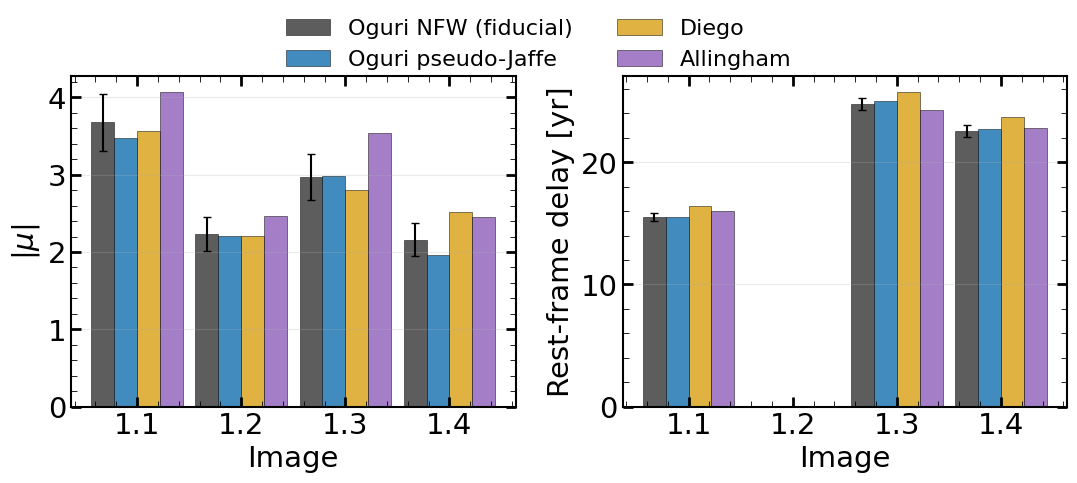

In [47]:
# Plot magnification and time-delay comparison for RX1.
# Oguri NFW is the fiducial model and is shown with the glafic posterior errors.
# Oguri pseudo-Jaffe is the profile-change cross-check supplied by Oguri; no posterior
# errors were supplied for this backup model, so it is plotted without error bars.
# Only the Oguri/glafic fiducial posterior errors are shown.
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))

image_order = [str(v) for v in coords['ID']]
x = np.arange(len(image_order))

oguri_jaffe_rx1 = {
    '1.1': {'mu':  3.4805, 'dt_day': 30111.277},
    '1.2': {'mu':  2.2098, 'dt_day':     0.000},
    '1.3': {'mu': -2.9888, 'dt_day': 48338.578},
    '1.4': {'mu': -1.9566, 'dt_day': 43930.859},
}


def _lens_value(image_id, model_name, col):
    return lens_df[(lens_df['ID'] == image_id) & (lens_df['model'] == model_name)][col].iloc[0]


plot_values = {
    'Oguri NFW (fiducial)': {
        'mu_abs': [_lens_value(img, 'Oguri fiducial', 'mu_abs') for img in image_order],
        'mu_err': [max(_lens_value(img, 'Oguri fiducial', 'mu_err_used'), 0.1 * _lens_value(img, 'Oguri fiducial', 'mu_abs')) for img in image_order],
        'dt_rest_yr': [_lens_value(img, 'Oguri fiducial', 'dt_rest_yr') for img in image_order],
        'dt_rest_err_yr': [_lens_value(img, 'Oguri fiducial', 'dt_err_day') / 365.25 / (1 + Z_SRC) for img in image_order],
    },
    'Oguri pseudo-Jaffe': {
        'mu_abs': [abs(oguri_jaffe_rx1[str(img)]['mu']) for img in image_order],
        'mu_err': [np.nan for _ in image_order],
        'dt_rest_yr': [oguri_jaffe_rx1[str(img)]['dt_day'] / 365.25 / (1 + Z_SRC) for img in image_order],
        'dt_rest_err_yr': [np.nan for _ in image_order],
    },
    'Diego': {
        'mu_abs': [_lens_value(img, 'Diego', 'mu_abs') for img in image_order],
        'mu_err': [np.nan for _ in image_order],
        'dt_rest_yr': [_lens_value(img, 'Diego', 'dt_rest_yr') for img in image_order],
        'dt_rest_err_yr': [np.nan for _ in image_order],
    },
    JOSEPH_MODEL_NAME: {
        'mu_abs': [_lens_value(img, JOSEPH_MODEL_NAME, 'mu_abs') for img in image_order],
        'mu_err': [np.nan for _ in image_order],
        'dt_rest_yr': [_lens_value(img, JOSEPH_MODEL_NAME, 'dt_rest_yr') for img in image_order],
        'dt_rest_err_yr': [np.nan for _ in image_order],
    },
}

colors = {
    'Oguri NFW (fiducial)': '0.25',
    'Oguri pseudo-Jaffe': 'tab:blue',
    'Diego': 'goldenrod',
    JOSEPH_MODEL_NAME: 'tab:purple',
}

# --- grouped bars for magnification and rest-frame time delays ---
width = 0.22
model_names = list(plot_values.keys())
offsets = (np.arange(len(model_names)) - (len(model_names) - 1) / 2) * width

for ax, quantity, err_quantity, ylabel in [
    (axes[0], 'mu_abs', 'mu_err', r'$|\mu|$'),
    (axes[1], 'dt_rest_yr', 'dt_rest_err_yr', r'Rest-frame delay [yr]'),
]:
    for offset, model_name in zip(offsets, model_names):
        values = np.asarray(plot_values[model_name][quantity], dtype=float)
        yerr = np.asarray(plot_values[model_name][err_quantity], dtype=float)
        yerr = None if np.all(~np.isfinite(yerr)) else yerr
        ax.bar(
            x + offset,
            values,
            width=width,
            yerr=yerr,
            capsize=3 if yerr is not None else 0,
            color=colors[model_name],
            edgecolor='black',
            linewidth=0.4,
            alpha=0.85,
            label=model_name,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(image_order)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Image')
    ax.grid(axis='y', alpha=0.25)

# axes[0].legend(frameon=False, fontsize=14 , ncols = 2, bbox_to_anchor = (0.4, 1))
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.1),
    ncol=2,
    frameon=False,
    fontsize=16,
)
# axes[0].set_ylim(0, 5)
# axes[1].legend(frameon=False, fontsize=14)

fig.tight_layout()
plt.savefig(OUTDIR / f'mu_dt_comparison_RX1.pdf', dpi=200, bbox_inches='tight')
plt.show()


## Propagate lensing changes into light curves

In [30]:
phot = Table.read(PHOT_FILE)
phot = phot[[str(v).startswith(f'{SOURCE_ID}.') for v in phot['ID_2']]]
phot.sort('ID_2')
print(phot['ID_2', 'RA', 'DEC'] if {'RA', 'DEC'}.issubset(phot.colnames) else phot['ID_2'])

band_wavelengths = {
    'F090W': 0.90,
    'F115W': 1.15,
    'F150W': 1.50,
    'F150W2': 1.50,
    'F200W': 2.00,
    'F210M': 2.10,
    'F277W': 2.77,
    'F300M': 3.00,
    'F322W2': 3.22,
    'F356W': 3.56,
    'F410M': 4.10,
    'F444W': 4.44,
}

# Keep the band grouping close to the original light-curve notebook.
faint_bands = ['F090W', 'F115W', 'F150W']
bright_bands = ['F150W2', 'F200W', 'F210M', 'F277W', 'F300M', 'F322W2', 'F356W', 'F410M', 'F444W']
bright_bands_shift = dict(zip(bright_bands, [2.1, 1.1, 1.1, 0.3, 0.45, 0.0, -0.1, 0.0, 0.2]))


LC_MU_ERR_FLOOR_FRAC = 0.08
LC_FLUX_ERR_FLOOR_FRAC = 0.04


def lightcurve_mu_err_for_id(model_name, phot_id, mu):
    """Magnification uncertainty used only for light-curve propagation.

    This follows the RX1_lc plotting convention, with an explicit floor of
    0.08 |mu|.  Use the raw external-model mu uncertainty when available,
    rather than any larger plotting/systematics floor stored elsewhere.
    """
    mu_floor = LC_MU_ERR_FLOOR_FRAC * abs(mu)
    raw_mu_err = np.nan

    if model_name == 'Oguri fiducial':
        og_id = phot_id_to_oguri_id(phot_id)
        raw_mu_err = symmetric_err(oguri[og_id]['mu'])
    elif model_name == 'Oguri pseudo-Jaffe':
        og_id = phot_id_to_oguri_id(phot_id)
        raw_mu_err = symmetric_err(oguri_jaffe[og_id]['mu'])
    elif model_name == JOSEPH_MODEL_NAME:
        jj = joseph_outputs[
            (joseph_outputs['system'] == 'RX1') &
            (joseph_outputs['image'].astype(str) == str(phot_id))
        ]
        if len(jj):
            raw_mu_err = float(jj.iloc[0]['mu_err'])

    if np.isfinite(raw_mu_err):
        return max(raw_mu_err, mu_floor)
    return mu_floor


def lens_params_for_id(model_name, phot_id):
    if model_name == 'Oguri pseudo-Jaffe':
        og_id = phot_id_to_oguri_id(phot_id)
        mu = float(oguri_jaffe[og_id]['mu'][0])
        mu_err = lightcurve_mu_err_for_id(model_name, phot_id, mu)
        dt = float(oguri_jaffe[og_id]['dt'][0])
        dt_err = symmetric_err(oguri_jaffe[og_id]['dt'])
        return mu, mu_err, dt, dt_err

    row = lens_df[(lens_df['ID'] == phot_id) & (lens_df['model'] == model_name)].iloc[0]
    mu = float(row['mu'])
    mu_err = lightcurve_mu_err_for_id(model_name, phot_id, mu)
    dt_err = float(row['dt_err_day']) if np.isfinite(row['dt_err_day']) else 0.0
    return mu, mu_err, float(row['dt_day']), dt_err


def flux_to_abmag_njy(flux_njy):
    flux_njy = np.asarray(flux_njy, dtype=float)
    return 31.4 - 2.5 * np.log10(flux_njy)


def abmag_err_from_flux_frac(frac_err):
    return 2.5 / np.log(10) * np.asarray(frac_err, dtype=float)


def lightcurve_table(model_name):
    rows = []
    for src in phot:
        phot_id = str(src['ID_2'])
        mu, mu_err, dt, dt_err = lens_params_for_id(model_name, phot_id)
        mu_abs = abs(mu)
        t_rest_yr = dt / 365.25 / (1 + Z_SRC)
        t_rest_err_yr = dt_err / 365.25 / (1 + Z_SRC)

        # Inverse-variance stack in observed flux space, then de-magnify.
        obs_flux = np.array([float(src[f'f_{b}']) for b in faint_bands])
        obs_err = np.array([float(src[f'e_{b}']) for b in faint_bands])
        obs_err = np.maximum(obs_err, LC_FLUX_ERR_FLOOR_FRAC * np.abs(obs_flux))
        valid = np.isfinite(obs_flux) & np.isfinite(obs_err) & (obs_err > 0) & (obs_flux > 0)
        w = 1.0 / obs_err[valid]**2
        f_stack_obs = np.sum(obs_flux[valid] * w) / np.sum(w)
        e_stack_obs = np.sqrt(1.0 / np.sum(w))
        f_stack = f_stack_obs / mu_abs
        m_stack = flux_to_abmag_njy(f_stack)
        e_stack_mag = abmag_err_from_flux_frac(np.sqrt((e_stack_obs / f_stack_obs)**2 + (mu_err / mu_abs)**2))
        rows.append({
            'ID': phot_id, 'model': model_name, 'band': 'SW_stack',
            'wave_um': np.nanmean([band_wavelengths[b] for b in faint_bands]),
            'time_rest_yr': t_rest_yr, 'time_rest_err_yr': t_rest_err_yr,
            'mag': m_stack, 'mag_err': e_stack_mag,
            'flux_njy': f_stack, 'flux_err_njy': f_stack * e_stack_mag / (2.5 / np.log(10)),
            'mu_abs': mu_abs,
        })

        for band in bright_bands:
            f_obs = float(src[f'f_{band}'])
            e_obs = float(src[f'e_{band}'])
            if not (np.isfinite(f_obs) and np.isfinite(e_obs) and f_obs > 0 and e_obs > 0):
                continue
            e_obs = max(e_obs, LC_FLUX_ERR_FLOOR_FRAC * abs(f_obs))
            f = f_obs / mu_abs
            frac = np.sqrt((e_obs / f_obs)**2 + (mu_err / mu_abs)**2)
            m = flux_to_abmag_njy(f)
            merr = abmag_err_from_flux_frac(frac)
            rows.append({
                'ID': phot_id, 'model': model_name, 'band': band,
                'wave_um': band_wavelengths[band],
                'time_rest_yr': t_rest_yr, 'time_rest_err_yr': t_rest_err_yr,
                'mag': m, 'mag_err': merr,
                'flux_njy': f, 'flux_err_njy': f * frac,
                'mu_abs': mu_abs,
            })
    return pd.DataFrame(rows)

lc_df = pd.concat([lightcurve_table(m) for m in ['Oguri fiducial', 'Oguri pseudo-Jaffe', 'Chema Case1', 'Diego', JOSEPH_MODEL_NAME]], ignore_index=True)
lc_df.to_csv(OUTDIR / f'lightcurve_by_lensmodel_source{SOURCE_ID}.csv', index=False)

with pd.option_context('display.precision', 4):
    display(lc_df.head(20))

ID_2         RA                DEC        
---- ------------------ ------------------
 1.1 332.95385254241927  -3.83206829976924
 1.2  332.9244063343455 -3.827680123780981
 1.3  332.9443607369648 -3.819110130596485
 1.4 332.94058464366725 -3.840669360770675


,ID,model,band,wave_um,time_rest_yr,time_rest_err_yr,mag,mag_err,flux_njy,flux_err_njy,mu_abs
0,1.1,Oguri fiducial,SW_stack,1.1833,15.5258,0.3551,28.8193,0.1412,10.7712,1.4004,3.68
1,1.1,Oguri fiducial,F150W2,1.5000,15.5258,0.3551,28.2439,0.1024,18.2992,1.7263,3.68
2,1.1,Oguri fiducial,F200W,2.0000,15.5258,0.3551,27.9696,0.1205,23.5599,2.6143,3.68
3,1.1,Oguri fiducial,F210M,2.1000,15.5258,0.3551,27.9011,0.1290,25.0945,2.9819,3.68
4,1.1,Oguri fiducial,F277W,2.7700,15.5258,0.3551,26.2796,0.1024,111.7262,10.5402,3.68
5,1.1,Oguri fiducial,F300M,3.0000,15.5258,0.3551,26.2746,0.1024,112.2443,10.5891,3.68
6,1.1,Oguri fiducial,F322W2,3.2200,15.5258,0.3551,25.6953,0.1024,191.3774,18.0545,3.68
7,1.1,Oguri fiducial,F356W,3.5600,15.5258,0.3551,25.3447,0.1024,264.3248,24.9363,3.68
8,1.1,Oguri fiducial,F410M,4.1000,15.5258,0.3551,25.5713,0.1024,214.5313,20.2388,3.68
9,1.1,Oguri fiducial,F444W,4.4400,15.5258,0.3551,25.4331,0.1024,243.6435,22.9853,3.68


In [31]:
def variability_stats(lc_df):
    rows = []
    for (model_name, band), g in lc_df.groupby(['model', 'band']):
        g = g[np.isfinite(g['mag']) & np.isfinite(g['mag_err']) & (g['mag_err'] > 0)]
        if len(g) < 2:
            continue
        if band == 'SW_stack':
            weights = 1.0 / g['mag_err'].values**2
            mean_mag = np.sum(g['mag'].values * weights) / np.sum(weights)
        else:
            mean_mag = np.nanmean(g['mag'].values)
        chi2_val = np.sum((g['mag'].values - mean_mag)**2 / g['mag_err'].values**2)
        dof = len(g) - 1
        idx_max = np.argmax(g['mag'].values)
        idx_min = np.argmin(g['mag'].values)
        delta_m = g['mag'].values[idx_max] - g['mag'].values[idx_min]
        delta_m_err = np.sqrt(g['mag_err'].values[idx_max]**2 + g['mag_err'].values[idx_min]**2)
        rows.append({
            'model': model_name,
            'band': band,
            'N': len(g),
            'mean_mag': mean_mag,
            'chi2': chi2_val,
            'chi2_red': chi2_val / dof,
            'p_value_const_flux': 1 - chi2.cdf(chi2_val, dof),
            'delta_m_max': delta_m,
            'delta_m_max_err': delta_m_err,
            'delta_m_significance': abs(delta_m) / delta_m_err,
        })
    return pd.DataFrame(rows)

var_df = variability_stats(lc_df)
var_df.to_csv(OUTDIR / f'variability_stats_by_lensmodel_source{SOURCE_ID}.csv', index=False)

with pd.option_context('display.precision', 4):
    display(var_df[var_df['band'].isin(['SW_stack', 'F200W', 'F277W', 'F356W', 'F444W'])])

,model,band,N,mean_mag,chi2,chi2_red,p_value_const_flux,delta_m_max,delta_m_max_err,delta_m_significance
1,Allingham,F200W,4,28.2142,1.5297,0.5099,6.7542e-01,0.1945,0.2266,0.8583
3,Allingham,F277W,4,26.6748,19.4209,6.4736,2.2373e-04,0.6153,0.1449,4.2480
6,Allingham,F356W,4,25.6825,15.1138,5.0379,1.7219e-03,0.5210,0.1449,3.5967
8,Allingham,F444W,4,25.8103,14.9168,4.9723,1.8891e-03,0.5453,0.1449,3.7647
9,Allingham,SW_stack,4,28.9770,0.6946,0.2315,8.7447e-01,0.1538,0.2291,0.6713
11,Chema Case1,F200W,4,28.0460,7.2892,2.4297,6.3229e-02,0.4738,0.2266,2.0908
13,Chema Case1,F277W,4,26.5066,29.9634,9.9878,1.4047e-06,0.7681,0.1449,5.3025
16,Chema Case1,F356W,4,25.5143,23.4010,7.8003,3.3310e-05,0.6737,0.1449,4.6511
18,Chema Case1,F444W,4,25.6421,25.7515,8.5838,1.0751e-05,0.6981,0.1449,4.8192
19,Chema Case1,SW_stack,4,28.7851,3.1168,1.0389,3.7396e-01,0.4117,0.2775,1.4840


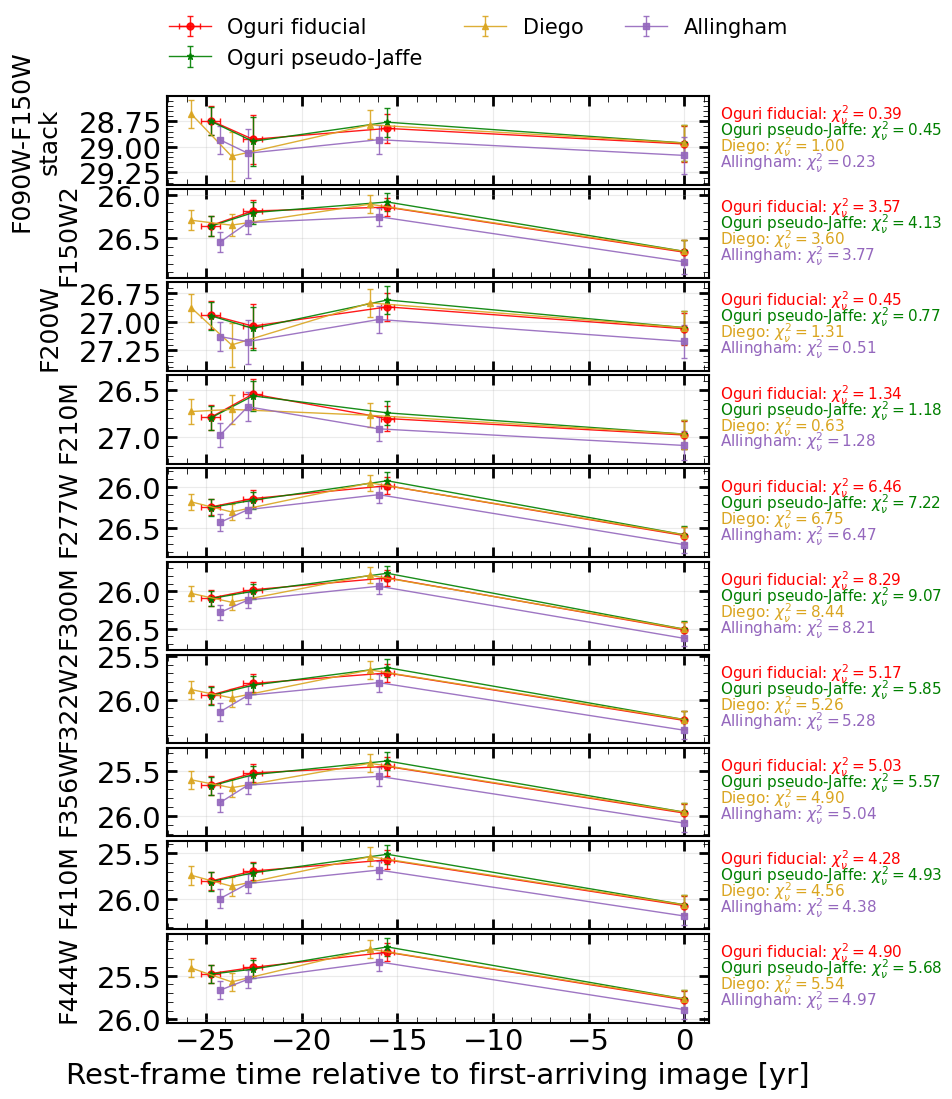

In [32]:
# Multi-panel light-curve comparison. The vertical offsets match the original visual convention.
plot_bands = ['SW_stack'] + bright_bands

colors = {
    'Oguri fiducial': 'red',
    'Oguri pseudo-Jaffe': 'green',
    'Diego': 'goldenrod',
    JOSEPH_MODEL_NAME: 'tab:purple',
}

markers = {
    'Oguri fiducial': 'o',
    'Oguri pseudo-Jaffe': '*',
    'Diego': '^',
    JOSEPH_MODEL_NAME: 's'
}

model_list = ['Oguri fiducial','Oguri pseudo-Jaffe', 'Diego', JOSEPH_MODEL_NAME]

fig, axes = plt.subplots(
    len(plot_bands), 1,
    figsize=(10, 1.1 * len(plot_bands)),
    sharex=True
)

if len(plot_bands) == 1:
    axes = [axes]

for ax, band in zip(axes, plot_bands):

    shift = 0.0 if band == 'SW_stack' else bright_bands_shift.get(band, 0.0)

    # --------------------------------------------------
    # plot light curves
    # --------------------------------------------------
    for model_name in model_list:

        g = lc_df[
            (lc_df['model'] == model_name) &
            (lc_df['band'] == band)
        ].sort_values('time_rest_yr')

        ax.errorbar(
            -g['time_rest_yr'],
            g['mag'] - shift,
            xerr=g['time_rest_err_yr'] if model_name == 'Oguri fiducial' else None,
            yerr=g['mag_err'],
            fmt=markers[model_name] + '-',
            ms=5,
            lw=1,
            capsize=2,
            color=colors[model_name],
            label=model_name,
            alpha=0.9,
        )

    # --------------------------------------------------
    # axis style
    # --------------------------------------------------
    ax.invert_yaxis()
    ax.grid(alpha=0.25)

    ylabel = 'F090W-F150W\nstack' if band == 'SW_stack' else band

    # 改成纵向 ylabel
    ax.set_ylabel(
        ylabel,
        rotation=90,
        fontsize=18,
        labelpad=12
    )

    # # --------------------------------------------------
    # # chi2_nu text (bottom row, horizontal)
    # # --------------------------------------------------
    # chi2_texts = []

    # for model_name in model_list:

    #     stat = var_df[
    #         (var_df['model'] == model_name) &
    #         (var_df['band'] == band)
    #     ]

    #     if len(stat):
    #         chi2_val = stat.iloc[0]['chi2_red']
    #         chi2_texts.append(
    #             rf'{model_name}: $\chi^2_\nu={chi2_val:.2f}$'
    #         )

    # ax.text(
    #     0.01,
    #     0.02,
    #     '   |   '.join(chi2_texts),
    #     transform=ax.transAxes,
    #     fontsize=10,
    #     va='bottom',
    #     ha='left'
    # )
    # --------------------------------------------------
    # chi2_nu text (right side, vertical list)
    # --------------------------------------------------
    y0 = 0.92
    dy = 0.18

    for i, model_name in enumerate(model_list):

        stat = var_df[
            (var_df['model'] == model_name) &
            (var_df['band'] == band)
        ]

        if len(stat):

            chi2_val = stat.iloc[0]['chi2_red']

            ax.text(
                1.02,                  # 放在 panel 右边
                y0 - i * dy,
                rf'{model_name}: $\chi^2_\nu={chi2_val:.2f}$',
                transform=ax.transAxes,
                fontsize=11,
                color=colors[model_name],
                va='top',
                ha='left'
            )

# --------------------------------------------------
# legend on top, outside panels
# --------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.94),
    ncol=3,
    frameon=False,
    fontsize=15
)

axes[-1].set_xlabel(
    r'Rest-frame time relative to first-arriving image [yr]'
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.subplots_adjust(hspace=0.05)
fig.savefig(
    OUTDIR / f'lightcurve_overlay_RX{SOURCE_ID}.pdf',
    dpi = 300,
    bbox_inches='tight'
)

plt.show()

## Propagate lensing changes into SEDs, colors, and temperature fits

In [33]:
# Original SED notebook order: the first two entries, F277W and F356W, were excluded from the fit via wave_jwst[2:].
jwstbands_original_order = ['F277W', 'F356W', 'F150W', 'F090W', 'F115W', 'F200W', 'F210M', 'F300M', 'F410M', 'F444W']
wave_jwst_original_order = np.array([band_wavelengths[b] for b in jwstbands_original_order])
SED_FIT_BANDS = jwstbands_original_order[2:]
print('SED fit bands:', SED_FIT_BANDS)

lambda_balmer_um = 3646e-4


def balmer_step(wl_obs_um, z, sharpness=50):
    wl_rest_um = np.asarray(wl_obs_um, dtype=float) / (1 + z)
    x = (lambda_balmer_um - wl_rest_um) / lambda_balmer_um
    return 1 - 1 / (1 + np.exp(-sharpness * x))


def blackbody_fnu_njy(wavelength_um, T, logLbol, z=Z_SRC):
    """Observed blackbody Fnu in nJy, matching the original notebook convention."""
    wave_obs = np.asarray(wavelength_um, dtype=float) * u.um
    wave_rest = wave_obs / (1 + z)
    nu_rest = (const.c.cgs / wave_rest).to(u.Hz)
    h = const.h.cgs
    c = const.c.cgs
    kB = const.k_B.cgs
    sigma = const.sigma_sb.cgs
    Bnu = (2 * h * nu_rest**3 / c**2) / np.expm1(h * nu_rest / (kB * T * u.K))
    Bnu *= 4 * np.pi
    Lbol = 10**logLbol * u.erg / u.s
    radius = np.sqrt(Lbol / (4 * np.pi * sigma * (T * u.K)**4))
    Lnu = 4 * np.pi * radius**2 * Bnu
    DL = cosmo.luminosity_distance(z).to(u.cm)
    Fnu = Lnu / (4 * np.pi * DL**2) / (1 + z)
    return Fnu.to(u.nJy).value * balmer_step(np.asarray(wavelength_um, dtype=float), z)


def build_sed_arrays(model_name, bands=SED_FIT_BANDS):
    sed = []
    for src in phot:
        phot_id = str(src['ID_2'])
        mu, mu_err, dt, dt_err = lens_params_for_id(model_name, phot_id)
        mu_abs = abs(mu)
        for band in bands:
            f_obs = float(src[f'f_{band}'])
            e_obs = float(src[f'e_{band}'])
            if not (np.isfinite(f_obs) and np.isfinite(e_obs) and f_obs > 0 and e_obs > 0):
                continue
            frac = np.sqrt((e_obs / f_obs)**2 + (mu_err / mu_abs)**2)
            sed.append({
                'ID': phot_id,
                'model': model_name,
                'band': band,
                'wave_um': band_wavelengths[band],
                'flux_njy': f_obs / mu_abs,
                'flux_err_njy': f_obs / mu_abs * frac,
                'mu_abs': mu_abs,
            })
    return pd.DataFrame(sed)

sed_df = pd.concat([build_sed_arrays(m) for m in ['Oguri fiducial', 'Chema Case1', 'Diego', JOSEPH_MODEL_NAME]], ignore_index=True)
sed_df.to_csv(OUTDIR / f'sed_points_by_lensmodel_source{SOURCE_ID}.csv', index=False)
display(sed_df.head())

SED fit bands: ['F150W', 'F090W', 'F115W', 'F200W', 'F210M', 'F300M', 'F410M', 'F444W']


,ID,model,band,wave_um,flux_njy,flux_err_njy,mu_abs
0,1.1,Oguri fiducial,F150W,1.50,17.445896,2.522947,3.68
1,1.1,Oguri fiducial,F090W,0.90,7.376259,1.815503,3.68
2,1.1,Oguri fiducial,F115W,1.15,9.361979,2.117236,3.68
3,1.1,Oguri fiducial,F200W,2.00,23.559853,2.614300,3.68
4,1.1,Oguri fiducial,F210M,2.10,25.094538,2.981915,3.68


In [34]:
sed_df

,ID,model,band,wave_um,flux_njy,flux_err_njy,mu_abs
0,1.1,Oguri fiducial,F150W,1.50,17.445896,2.522947,3.680
1,1.1,Oguri fiducial,F090W,0.90,7.376259,1.815503,3.680
2,1.1,Oguri fiducial,F115W,1.15,9.361979,2.117236,3.680
3,1.1,Oguri fiducial,F200W,2.00,23.559853,2.614300,3.680
4,1.1,Oguri fiducial,F210M,2.10,25.094538,2.981915,3.680
...,...,...,...,...,...,...,...
123,1.4,Allingham,F200W,2.00,17.794145,3.145735,2.448
124,1.4,Allingham,F210M,2.10,28.194818,4.079157,2.448
125,1.4,Allingham,F300M,3.00,85.679599,8.082997,2.448
126,1.4,Allingham,F410M,4.10,169.331063,15.974661,2.448


In [35]:
def joint_sed_model(xdata, *params):
    """Per-image blackbody temperatures/luminosities plus shared power-law."""
    wave_um, image_index = xdata
    image_index = np.asarray(image_index, dtype=int)
    wave_um = np.asarray(wave_um, dtype=float)
    n_images = len(image_ids)
    a_pl = params[2 * n_images]
    alpha = params[2 * n_images + 1]
    out = np.zeros_like(wave_um, dtype=float)
    for j in range(n_images):
        mask = image_index == j
        T = params[2*j]
        logL = params[2*j + 1]
        out[mask] = blackbody_fnu_njy(wave_um[mask], T, logL, z=Z_SRC) + a_pl * (wave_um[mask] / 1.0)**alpha
    return out


def fit_sed_model(model_name):
    global image_ids
    g = sed_df[sed_df['model'] == model_name].copy()
    image_ids = list(phot['ID_2'])
    image_to_idx = {str(v): i for i, v in enumerate(image_ids)}
    g['image_index'] = [image_to_idx[v] for v in g['ID']]
    xdata = (g['wave_um'].values, g['image_index'].values)
    y = g['flux_njy'].values
    yerr = g['flux_err_njy'].values
    n_images = len(image_ids)

    p0 = []
    for _ in range(n_images):
        p0 += [4700, 44.5]
    p0 += [0.5, -0.5]
    lower = [3500, 44.0] * n_images + [0.0, -3.0]
    upper = [6000, 50.0] * n_images + [100.0, 1.0]

    popt, pcov = curve_fit(
        joint_sed_model, xdata, y,
        p0=p0, sigma=yerr, absolute_sigma=True,
        bounds=(lower, upper), maxfev=20000,
    )
    perr = np.sqrt(np.diag(pcov))
    rows = []
    for j, image_id in enumerate(image_ids):
        rows.append({
            'model': model_name,
            'ID': str(image_id),
            'T_K': popt[2*j],
            'T_err_K': perr[2*j],
            'logLbol': popt[2*j + 1],
            'logLbol_err': perr[2*j + 1],
            'A_PL': popt[2*n_images],
            'alpha_PL': popt[2*n_images + 1],
        })
    model_flux = joint_sed_model(xdata, *popt)
    chi2_val = np.sum(((y - model_flux) / yerr)**2)
    dof = len(y) - len(popt)
    return pd.DataFrame(rows), popt, pcov, chi2_val, dof

fit_tables = []
fit_cache = {}
for model_name in ['Oguri fiducial', 'Diego', JOSEPH_MODEL_NAME]:
    tab, popt, pcov, chi2_val, dof = fit_sed_model(model_name)
    tab['chi2'] = chi2_val
    tab['dof'] = dof
    tab['chi2_red'] = chi2_val / dof
    fit_tables.append(tab)
    fit_cache[model_name] = (popt, pcov)

sedfit_df = pd.concat(fit_tables, ignore_index=True)
sedfit_df.to_csv(OUTDIR / f'sed_temperature_fits_by_lensmodel_source{SOURCE_ID}.csv', index=False)

with pd.option_context('display.precision', 4):
    display(sedfit_df)

,model,ID,T_K,T_err_K,logLbol,logLbol_err,A_PL,alpha_PL,chi2,dof,chi2_red
0,Oguri fiducial,1.1,3686.4171,185.6612,44.4570,0.0419,9.1407,0.8400,15.0300,22,0.6832
1,Oguri fiducial,1.2,3515.1764,277.9159,44.2096,0.0593,9.1407,0.8400,15.0300,22,0.6832
2,Oguri fiducial,1.3,3776.3676,214.5183,44.3296,0.0448,9.1407,0.8400,15.0300,22,0.6832
3,Oguri fiducial,1.4,3906.4416,219.0448,44.3602,0.0438,9.1407,0.8400,15.0300,22,0.6832
4,Diego,1.1,3717.0740,180.1082,44.4699,0.0411,9.1681,0.8319,17.9335,22,0.8152
5,Diego,1.2,3530.6697,275.1740,44.2131,0.0584,9.1681,0.8319,17.9335,22,0.8152
6,Diego,1.3,3838.6389,203.3265,44.3533,0.0431,9.1681,0.8319,17.9335,22,0.8152
7,Diego,1.4,3773.3364,241.3798,44.2950,0.0480,9.1681,0.8319,17.9335,22,0.8152
8,Allingham,1.1,3709.4964,181.4811,44.4119,0.0413,8.0578,0.8382,14.5289,22,0.6604
9,Allingham,1.2,3548.3342,272.0732,44.1628,0.0578,8.0578,0.8382,14.5289,22,0.6604


In [36]:
og_fit = sedfit_df[sedfit_df['model'] == 'Oguri fiducial'].set_index('ID')
sed_delta_rows = []
for model_name in ['Diego', JOSEPH_MODEL_NAME]:
    mm = sedfit_df[sedfit_df['model'] == model_name].set_index('ID')
    for image_id in og_fit.index:
        sed_delta_rows.append({
            'ID': image_id,
            'model': model_name,
            'delta_T_K': mm.loc[image_id, 'T_K'] - og_fit.loc[image_id, 'T_K'],
            'delta_T_sigma': (mm.loc[image_id, 'T_K'] - og_fit.loc[image_id, 'T_K']) /
                             np.sqrt(mm.loc[image_id, 'T_err_K']**2 + og_fit.loc[image_id, 'T_err_K']**2),
            'delta_logLbol': mm.loc[image_id, 'logLbol'] - og_fit.loc[image_id, 'logLbol'],
        })
sed_delta_df = pd.DataFrame(sed_delta_rows)
sed_delta_df.to_csv(OUTDIR / f'sed_temperature_delta_vs_oguri_source{SOURCE_ID}.csv', index=False)

with pd.option_context('display.precision', 4):
    display(sed_delta_df)

summary_sed = sed_delta_df.groupby('model').agg(
    max_abs_delta_T_K=('delta_T_K', lambda x: np.nanmax(np.abs(x))),
    max_abs_delta_T_sigma=('delta_T_sigma', lambda x: np.nanmax(np.abs(x))),
    max_abs_delta_logLbol=('delta_logLbol', lambda x: np.nanmax(np.abs(x))),
).reset_index()
display(summary_sed)

,ID,model,delta_T_K,delta_T_sigma,delta_logLbol
0,1.1,Diego,30.6569,0.1185,0.0129
1,1.2,Diego,15.4933,0.0396,0.0034
2,1.3,Diego,62.2713,0.2107,0.0237
3,1.4,Diego,-133.1052,-0.4084,-0.0652
4,1.1,Allingham,23.0793,0.0889,-0.0451
5,1.2,Allingham,33.1578,0.0853,-0.0468
6,1.3,Allingham,-53.1285,-0.1708,-0.0738
7,1.4,Allingham,1.6971,0.0055,-0.0542


,model,max_abs_delta_T_K,max_abs_delta_T_sigma,max_abs_delta_logLbol
0,Allingham,53.128528,0.170814,0.073801
1,Diego,133.105180,0.408358,0.065158


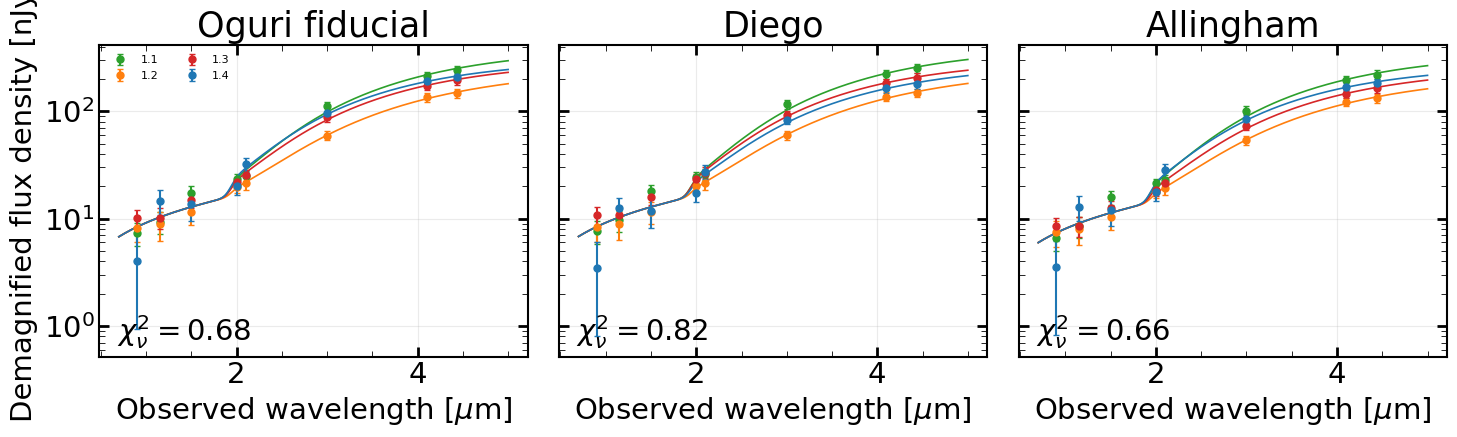

In [37]:
# Plot SED points and fitted curves for each lens model.
fit_wave = np.linspace(0.7, 5.0, 400)
image_ids = list(phot['ID_2'])
image_colors = dict(zip([str(v) for v in image_ids], ['tab:green', 'tab:orange', 'tab:red', 'tab:blue', 'tab:purple', 'tab:brown']))

sed_plot_models = ['Oguri fiducial',  'Diego', JOSEPH_MODEL_NAME]
fig, axes = plt.subplots(1, len(sed_plot_models), figsize=(5 * len(sed_plot_models), 4.8), sharey=True)
for ax, model_name in zip(axes, sed_plot_models):
    gmodel = sed_df[sed_df['model'] == model_name]
    fit = sedfit_df[sedfit_df['model'] == model_name].set_index('ID')
    a_pl = fit.iloc[0]['A_PL']
    alpha_pl = fit.iloc[0]['alpha_PL']
    for image_id in [str(v) for v in image_ids]:
        g = gmodel[gmodel['ID'] == image_id].sort_values('wave_um')
        color = image_colors[image_id]
        ax.errorbar(g['wave_um'], g['flux_njy'], yerr=g['flux_err_njy'], fmt='o', ms=5, capsize=2, color=color, label=image_id)
        T = fit.loc[image_id, 'T_K']
        logL = fit.loc[image_id, 'logLbol']
        curve = blackbody_fnu_njy(fit_wave, T, logL, z=Z_SRC) + a_pl * fit_wave**alpha_pl
        ax.plot(fit_wave, curve, color=color, lw=1.2)
    ax.set_title(model_name)
    ax.set_xlabel(r'Observed wavelength [$\mu$m]')
    ax.set_yscale('log')
    ax.grid(alpha=0.25)
    ax.text(0.04, 0.05, r'$\chi^2_\nu=%.2f$' % fit.iloc[0]['chi2_red'], transform=ax.transAxes)
axes[0].set_ylabel('Demagnified flux density [nJy]')
axes[0].legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(OUTDIR / f'sed_temperature_lensmodel_comparison_source{SOURCE_ID}.pdf')
plt.show()

In [38]:
# Colors should be nearly invariant to lensing model because lensing is achromatic per image.
color_pairs = [('F200W', 'F444W'), ('F150W', 'F200W'), ('F090W', 'F150W')]
color_rows = []
for model_name in ['Oguri fiducial', 'Diego', JOSEPH_MODEL_NAME]:
    lc_model = lc_df[lc_df['model'] == model_name]
    for image_id in [str(v) for v in phot['ID_2']]:
        for b1, b2 in color_pairs:
            g1 = lc_model[(lc_model['ID'] == image_id) & (lc_model['band'] == b1)]
            g2 = lc_model[(lc_model['ID'] == image_id) & (lc_model['band'] == b2)]
            if len(g1) and len(g2):
                color_rows.append({
                    'model': model_name,
                    'ID': image_id,
                    'color': f'{b1}-{b2}',
                    'mag_color': float(g1.iloc[0]['mag'] - g2.iloc[0]['mag']),
                    'mag_color_err': float(np.sqrt(g1.iloc[0]['mag_err']**2 + g2.iloc[0]['mag_err']**2)),
                })
color_df = pd.DataFrame(color_rows)
color_df.to_csv(OUTDIR / f'colors_by_lensmodel_source{SOURCE_ID}.csv', index=False)

# Show model-to-Oguri color differences.
og_color = color_df[color_df['model'] == 'Oguri fiducial'].set_index(['ID', 'color'])
color_delta = []
for model_name in [ 'Diego', JOSEPH_MODEL_NAME]:
    mm = color_df[color_df['model'] == model_name].set_index(['ID', 'color'])
    for idx in og_color.index:
        color_delta.append({
            'ID': idx[0],
            'color': idx[1],
            'model': model_name,
            'delta_color_mag': mm.loc[idx, 'mag_color'] - og_color.loc[idx, 'mag_color'],
        })
color_delta_df = pd.DataFrame(color_delta)
with pd.option_context('display.precision', 5):
    display(color_delta_df)
print('Maximum absolute color change from lens model: %.4g mag' % np.nanmax(np.abs(color_delta_df['delta_color_mag'])))

,ID,color,model,delta_color_mag
0,1.1,F200W-F444W,Diego,3.55271e-15
1,1.2,F200W-F444W,Diego,0.00000e+00
2,1.3,F200W-F444W,Diego,-3.55271e-15
3,1.4,F200W-F444W,Diego,0.00000e+00
4,1.1,F200W-F444W,Allingham,3.55271e-15
5,1.2,F200W-F444W,Allingham,0.00000e+00
6,1.3,F200W-F444W,Allingham,0.00000e+00
7,1.4,F200W-F444W,Allingham,0.00000e+00


Maximum absolute color change from lens model: 3.553e-15 mag


## Summary numbers for text / response draft

In [39]:
# One-cell numerical summary suitable for a referee response paragraph.
lens_summary = summary_lens.set_index('model')
sed_summary = summary_sed.set_index('model')
var_key = var_df[var_df['band'].isin(['SW_stack', 'F200W', 'F444W'])].copy()

print('Lens-model-family spread relative to Oguri:')
for model_name in ['Chema Case1', 'Diego', JOSEPH_MODEL_NAME]:
    print(f"  {model_name}:")
    print('    max |Delta |mu|/|mu|| = %.2f' % lens_summary.loc[model_name, 'max_abs_frac_mu'])
    print('    max demagnified-mag shift = %.2f mag' % lens_summary.loc[model_name, 'max_abs_mag_shift'])
    print('    max time-delay shift = %.0f day = %.2f rest-frame yr' % (
        lens_summary.loc[model_name, 'max_abs_delta_dt_day'],
        lens_summary.loc[model_name, 'max_abs_delta_dt_rest_yr'],
    ))
    if model_name in sed_summary.index:
        print('    max |Delta T| = %.0f K (%.2f sigma)' % (
            sed_summary.loc[model_name, 'max_abs_delta_T_K'],
            sed_summary.loc[model_name, 'max_abs_delta_T_sigma'],
        ))
        print('    max |Delta log Lbol| = %.2f dex' % sed_summary.loc[model_name, 'max_abs_delta_logLbol'])
    else:
        print('    SED/temperature fit summary not computed for this model')

print('\nSelected variability statistics:')
display(var_key.sort_values(['band', 'model']))

print('\nInterpretation notes:')
print('- Chema Case1, Diego Case2, and the Joseph model provide external checks on the fiducial glafic lensing correction for this system.')
print('- The main propagation of magnification differences is a per-image vertical shift in demagnified magnitudes and luminosities.')
print('- Colors are unchanged to numerical precision because the lensing correction is achromatic for each image.')
print('- The Case1--Diego Case2 spread and the Joseph-model offset can be quoted as alternative-model systematics; they are distinct from Oguri posterior errors.')

Lens-model-family spread relative to Oguri:
  Chema Case1:
    max |Delta |mu|/|mu|| = 0.18
    max demagnified-mag shift = 0.22 mag
    max time-delay shift = 1359 day = 0.70 rest-frame yr
    SED/temperature fit summary not computed for this model
  Diego:
    max |Delta |mu|/|mu|| = 0.16
    max demagnified-mag shift = 0.16 mag
    max time-delay shift = 2158 day = 1.11 rest-frame yr
    max |Delta T| = 133 K (0.41 sigma)
    max |Delta log Lbol| = 0.07 dex
  Allingham:
    max |Delta |mu|/|mu|| = 0.19
    max demagnified-mag shift = 0.19 mag
    max time-delay shift = 948 day = 0.49 rest-frame yr
    max |Delta T| = 53 K (0.17 sigma)
    max |Delta log Lbol| = 0.07 dex

Selected variability statistics:


,model,band,N,mean_mag,chi2,chi2_red,p_value_const_flux,delta_m_max,delta_m_max_err,delta_m_significance
1,Allingham,F200W,4,28.214243,1.529748,0.509916,0.675422,0.194519,0.226620,0.858349
11,Chema Case1,F200W,4,28.046043,7.289228,2.429743,0.063229,0.473817,0.226620,2.090802
21,Diego,F200W,4,28.091989,3.931029,1.310343,0.269009,0.368658,0.226620,1.626770
31,Oguri fiducial,F200W,4,28.077374,1.338264,0.446088,0.720068,0.191642,0.186357,1.028361
41,Oguri pseudo-Jaffe,F200W,4,28.066430,2.319578,0.773193,0.508781,0.249438,0.226620,1.100690
8,Allingham,F444W,4,25.810324,14.916829,4.972276,0.001889,0.545342,0.144855,3.764737
18,Chema Case1,F444W,4,25.642124,25.751532,8.583844,0.000011,0.698084,0.144855,4.819185
28,Diego,F444W,4,25.688069,16.628808,5.542936,0.000842,0.569265,0.144855,3.929887
38,Oguri fiducial,F444W,4,25.673455,14.709522,4.903174,0.002082,0.543835,0.144855,3.754331
48,Oguri pseudo-Jaffe,F444W,4,25.662510,17.025943,5.675314,0.000698,0.594626,0.144855,4.104968



Interpretation notes:
- Chema Case1, Diego Case2, and the Joseph model provide external checks on the fiducial glafic lensing correction for this system.
- The main propagation of magnification differences is a per-image vertical shift in demagnified magnitudes and luminosities.
- Colors are unchanged to numerical precision because the lensing correction is achromatic for each image.
- The Case1--Diego Case2 spread and the Joseph-model offset can be quoted as alternative-model systematics; they are distinct from Oguri posterior errors.


## LaTeX table: six lens-model comparison

This section generates a compact LaTeX table comparing `mu` and time delay for the lens-model columns:

1. Oguri NFW profile,
2. Oguri pseudo-Jaffe profile,
3. Diego et al. Case2 sampled at the Oguri NFW model-output image positions,
4. Joseph/Allingham model output when available,
5. Cerny et al. in prep. placeholder,
6. Allingham et al. in prep. placeholder.

The Oguri NFW/Jaffe values below are the model outputs supplied for the referee-response cross-check.  Diego et al. Case2 is evaluated from the Case2 maps at the Oguri NFW `(X,Y)` image positions and re-scaled from the provided `z=3` maps to `z=4.3`; these sampled values are used as the final Diego et al. entries throughout the notebook.

In [40]:
# -----------------------------------------------------------------------------
# Five-model mu/time-delay comparison table for the referee response.
# -----------------------------------------------------------------------------

OGURI_PROFILE_BLOCKS = {
    'Oguri NFW': {
        'RX1': [
            ('1.1', -44.9070, -10.5678,  3.7267, 30033.709),
            ('1.2',  60.5775,   4.7051,  2.2718,     0.000),
            ('1.3', -10.7754,  35.3269, -3.0010, 47884.862),
            ('1.4',   2.6140, -42.2604, -2.2099, 43582.244),
            ('1.5',  -0.7705,  -0.5178,  0.0519, 61149.138),
        ],
        # RX2 rows are labelled by matching the supplied Oguri (X,Y) to
        # lens_lrd_coords.fits sky positions.  The supplied list order has
        # the last three images as 2.4, 2.5, 2.3 rather than 2.3, 2.4, 2.5.
        'RX2': [
            ('2.1',   2.8969, -21.5711, -1.1565, 57881.566),
            ('2.2',   1.4017, -11.1716,  1.0452, 58366.917),
            ('2.4',  50.1004,  32.4185,  3.4220,     0.000),
            ('2.5', -11.1643,  52.9874, -7.8093, 14873.565),
            ('2.3', -48.6402,  22.7148,  3.4545,  8298.088),
        ],
    },
    'Oguri Jaffe': {
        'RX1': [
            ('1.1', -44.9239, -10.7422,  3.4805, 30111.277),
            ('1.2',  60.6399,   4.7794,  2.2098,     0.000),
            ('1.3', -10.8862,  35.4660, -2.9888, 48338.578),
            ('1.4',   2.6911, -42.1844, -1.9566, 43930.859),
            ('1.5',  -0.7990,  -0.4041,  0.1029, 61316.038),
        ],
        # Same RX2 relabelling as above, based on position matching.
        'RX2': [
            ('2.1',   2.9897, -22.6224, -1.0638, 59341.648),
            ('2.2',   1.3860, -12.9054,  0.7985, 59868.265),
            ('2.4',  50.1496,  32.7729,  3.4631,     0.000),
            ('2.5', -11.0899,  52.9974, -8.6389, 14612.751),
            ('2.3', -48.4337,  22.5986,  3.3015,  8339.919),
        ],
    },
}


def rows_from_oguri_profile(model_name, block):
    rows = []
    for system, records in block.items():
        for image_id, x_arcsec, y_arcsec, mu, dt_day in records:
            rows.append({
                'model': model_name,
                'system': system,
                'image': image_id,
                'x_arcsec': x_arcsec,
                'y_arcsec': y_arcsec,
                'mu': mu,
                'mu_abs': abs(mu),
                'dt_day': dt_day,
                'position_source': 'model output',
            })
    return rows


def chema_case2_rows_for_table():
    """Evaluate Diego/Chema Case2 at the Oguri NFW model-output positions."""
    oguri_nfw_xy_by_system = {
        system: [(image_id, x_arcsec, y_arcsec) for image_id, x_arcsec, y_arcsec, mu, dt_day in records]
        for system, records in OGURI_PROFILE_BLOCKS['Oguri NFW'].items()
    }
    sampled = chema_values_at_xy(
        2,
        oguri_nfw_xy_by_system,
        beta_exclude={'RX1': {'1.5'}},
        model_label='Diego',
    )
    sampled = sampled.copy()
    sampled['position_source'] = 'Oguri NFW model-output xy'
    return sampled.to_dict('records')




def joseph_rows_for_table():
    rows = []
    coord_tab = Table.read(COORD_FILE)
    coord_by_id = {str(row['ID']): row for row in coord_tab}
    for system, image_ids in {'RX1': [f'1.{i}' for i in range(1, 6)],
                              'RX2': [f'2.{i}' for i in range(1, 6)]}.items():
        sub = joseph_outputs[joseph_outputs['system'] == system].copy()
        by_image = sub.set_index('image')
        for image_id in image_ids:
            if image_id not in by_image.index:
                rows.append({
                    'model': JOSEPH_MODEL_NAME,
                    'system': system,
                    'image': image_id,
                    'x_arcsec': np.nan,
                    'y_arcsec': np.nan,
                    'mu': np.nan,
                    'mu_abs': np.nan,
                    'dt_day': np.nan,
                    'position_source': 'missing Joseph output',
                })
                continue
            jj = by_image.loc[image_id]
            if image_id in coord_by_id:
                # Store x/y in the same Chema/glafic-like convention used elsewhere.
                ref_model = ChemaModel(2)
                x, y = ref_model.xy_from_radec(jj['RA'], jj['DEC'])
                x = float(np.atleast_1d(x)[0])
                y = float(np.atleast_1d(y)[0])
            else:
                x, y = np.nan, np.nan
            rows.append({
                'model': JOSEPH_MODEL_NAME,
                'system': system,
                'image': image_id,
                'x_arcsec': x,
                'y_arcsec': y,
                'mu': jj['mu'],
                'mu_abs': abs(jj['mu']),
                'dt_day': jj['dt_day'],
                'position_source': jj['position_source'],
            })
    return rows

# Interface for pending lens models.  When values arrive, replace the empty list
# with dictionaries or tuples that include system/image/mu/dt_day.  Example:
# PENDING_MODEL_INPUTS['Cerny et al. in prep.'] = [
#     {'system': 'RX1', 'image': '1.1', 'mu': 3.5, 'dt_day': 30100.0}, ...]
PENDING_MODEL_INPUTS = {
    'Cerny et al. in prep.': [],
    'Allingham et al. in prep.': [],
}


def rows_from_pending_model(model_name, records):
    rows = []
    for rec in records:
        if isinstance(rec, dict):
            rows.append({
                'model': model_name,
                'system': rec.get('system'),
                'image': rec.get('image'),
                'x_arcsec': rec.get('x_arcsec', np.nan),
                'y_arcsec': rec.get('y_arcsec', np.nan),
                'mu': rec.get('mu', np.nan),
                'mu_abs': abs(rec.get('mu', np.nan)) if np.isfinite(rec.get('mu', np.nan)) else np.nan,
                'dt_day': rec.get('dt_day', np.nan),
                'position_source': rec.get('position_source', 'pending external model'),
            })
        else:
            system, image_id, mu, dt_day = rec[:4]
            rows.append({
                'model': model_name,
                'system': system,
                'image': image_id,
                'x_arcsec': np.nan,
                'y_arcsec': np.nan,
                'mu': mu,
                'mu_abs': abs(mu),
                'dt_day': dt_day,
                'position_source': 'pending external model',
            })
    return rows


all_rows = []
for name, block in OGURI_PROFILE_BLOCKS.items():
    all_rows.extend(rows_from_oguri_profile(name, block))
all_rows.extend(chema_case2_rows_for_table())
all_rows.extend(joseph_rows_for_table())
for name, records in PENDING_MODEL_INPUTS.items():
    all_rows.extend(rows_from_pending_model(name, records))

# Ensure placeholders appear even before the pending values arrive.
base_images = [('RX1', f'1.{i}') for i in range(1, 6)] + [('RX2', f'2.{i}') for i in range(1, 6)]
for model_name in PENDING_MODEL_INPUTS:
    existing = {(r['system'], r['image']) for r in all_rows if r['model'] == model_name}
    for system, image_id in base_images:
        if (system, image_id) not in existing:
            all_rows.append({
                'model': model_name,
                'system': system,
                'image': image_id,
                'x_arcsec': np.nan,
                'y_arcsec': np.nan,
                'mu': np.nan,
                'mu_abs': np.nan,
                'dt_day': np.nan,
                'position_source': 'placeholder',
            })

five_model_df = pd.DataFrame(all_rows)
five_model_df['dt_rest_yr'] = five_model_df['dt_day'] / 365.25 / (1 + Z_SRC)
five_model_df = five_model_df.sort_values(['system', 'image', 'model']).reset_index(drop=True)
five_model_df.to_csv(OUTDIR / 'five_lensmodel_mu_timedelay_comparison_long.csv', index=False)

# Wide table for LaTeX.  Use signed mu, because image parity is useful in lens-model comparisons.
model_order = ['Oguri NFW', 'Oguri Jaffe', 'Diego', JOSEPH_MODEL_NAME, 'Cerny et al. in prep.', 'Allingham et al. in prep.']
wide = five_model_df.pivot_table(
    index=['system', 'image'],
    columns='model',
    values=['mu', 'dt_day'],
    aggfunc='first',
)
wide = wide.reindex(columns=pd.MultiIndex.from_product([['mu', 'dt_day'], model_order]))
wide = wide.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)
wide = wide.reindex(columns=pd.MultiIndex.from_product([model_order, ['mu', 'dt_day']]))
wide = wide.reset_index()
wide.columns = [
    'System' if c == ('system', '') else 'Image' if c == ('image', '') else
    (f'{c[0]} $\mu$' if c[1] == 'mu' else f'{c[0]} $\Delta t$ [day]')
    for c in wide.columns
]

# Human-friendly formatting while retaining a separate machine-readable CSV above.
fmt_wide = wide.copy()
for col in fmt_wide.columns:
    if '$\\mu$' in col:
        fmt_wide[col] = fmt_wide[col].map(lambda x: '--' if pd.isna(x) else f'{x:.3f}')
    elif '$\\Delta t$' in col:
        fmt_wide[col] = fmt_wide[col].map(lambda x: '--' if pd.isna(x) else f'{x:.0f}')

latex_table = fmt_wide.to_latex(
    index=False,
    escape=False,
    column_format='ll' + 'rr' * len(model_order),
    caption=(
        'Comparison of signed magnification $\\mu$ and relative time delay $\\Delta t$ '
        'for six lens-model families.  Cerny et al. and Allingham et al. are '
        'left as placeholders pending their in-preparation model outputs.'
    ),
    label='tab:lensmodel_mu_timedelay_comparison',
)

tex_path = OUTDIR / 'five_lensmodel_mu_timedelay_comparison_table.tex'
with open(tex_path, 'w') as f:
    f.write(latex_table)

print('Wrote long-form CSV:', OUTDIR / 'five_lensmodel_mu_timedelay_comparison_long.csv')
print('Wrote LaTeX table:', tex_path)
display(fmt_wide)
print(latex_table)

Wrote long-form CSV: /Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/code/referee_Chema_lensmodel_outputs/five_lensmodel_mu_timedelay_comparison_long.csv
Wrote LaTeX table: /Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/code/referee_Chema_lensmodel_outputs/five_lensmodel_mu_timedelay_comparison_table.tex


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


,System,Image,Oguri NFW $\mu$,Oguri NFW $\Delta t$ [day],Oguri Jaffe $\mu$,Oguri Jaffe $\Delta t$ [day],Diego $\mu$,Diego $\Delta t$ [day],Allingham $\mu$,Allingham $\Delta t$ [day],Cerny et al. in prep. $\mu$,Cerny et al. in prep. $\Delta t$ [day],Allingham et al. in prep. $\mu$,Allingham et al. in prep. $\Delta t$ [day]
0,RX1,1.1,3.727,30034,3.481,30111,3.550,31847,4.073,30915,--,--,--,--
1,RX1,1.2,2.272,0,2.210,0,2.203,0,2.472,0,--,--,--,--
2,RX1,1.3,-3.001,47885,-2.989,48339,-2.804,49925,-3.537,46962,--,--,--,--
3,RX1,1.4,-2.210,43582,-1.957,43931,-2.533,45806,-2.448,44161,--,--,--,--
4,RX1,1.5,0.052,61149,0.103,61316,0.069,63431,--,--,--,--,--,--
5,RX2,2.1,-1.157,57882,-1.064,59342,-1.631,59401,-1.371,58136,--,--,--,--
6,RX2,2.2,1.045,58367,0.798,59868,1.269,59840,2.481,57571,--,--,--,--
7,RX2,2.3,3.454,8298,3.301,8340,4.421,9009,3.917,7514,--,--,--,--
8,RX2,2.4,3.422,0,3.463,0,4.427,0,4.222,0,--,--,--,--
9,RX2,2.5,-7.809,14874,-8.639,14613,-9.937,15621,-8.284,13165,--,--,--,--


\begin{table}
\caption{Comparison of signed magnification $\mu$ and relative time delay $\Delta t$ for six lens-model families.  Cerny et al. and Allingham et al. are left as placeholders pending their in-preparation model outputs.}
\label{tab:lensmodel_mu_timedelay_comparison}
\begin{tabular}{llrrrrrrrrrrrr}
\toprule
System & Image & Oguri NFW $\mu$ & Oguri NFW $\Delta t$ [day] & Oguri Jaffe $\mu$ & Oguri Jaffe $\Delta t$ [day] & Diego $\mu$ & Diego $\Delta t$ [day] & Allingham $\mu$ & Allingham $\Delta t$ [day] & Cerny et al. in prep. $\mu$ & Cerny et al. in prep. $\Delta t$ [day] & Allingham et al. in prep. $\mu$ & Allingham et al. in prep. $\Delta t$ [day] \\
\midrule
RX1 & 1.1 & 3.727 & 30034 & 3.481 & 30111 & 3.550 & 31847 & 4.073 & 30915 & -- & -- & -- & -- \\
RX1 & 1.2 & 2.272 & 0 & 2.210 & 0 & 2.203 & 0 & 2.472 & 0 & -- & -- & -- & -- \\
RX1 & 1.3 & -3.001 & 47885 & -2.989 & 48339 & -2.804 & 49925 & -3.537 & 46962 & -- & -- & -- & -- \\
RX1 & 1.4 & -2.210 & 43582 & -1.957 & 43

## Split LaTeX table: magnification and time delay

This cell writes a publication-style LaTeX table with two separate tabular blocks: one for signed magnification and one for relative time delay.  It uses the corrected RX2 image matching from the long-form comparison table above.

In [41]:
# -----------------------------------------------------------------------------
# Publication-style split table: one tabular for mu, one for Delta t.
# -----------------------------------------------------------------------------

split_model_order = ['Oguri NFW', 'Oguri Jaffe', 'Diego',  'Cerny et al. in prep.', JOSEPH_MODEL_NAME]
split_model_headers = ['Oguri NFW', 'Oguri Jaffe', 'Diego',  'Cerny et al.', JOSEPH_MODEL_NAME]
split_image_order = [('RX1', f'1.{i}') for i in range(1, 6)] + [('RX2', f'2.{i}') for i in range(1, 6)]
macro_for_system = {'RX1': r'\tgta', 'RX2': r'\tgtb'}

split_source_df = five_model_df.copy()


def get_split_value(system, image, model_name, value_col):
    row = split_source_df[
        (split_source_df['system'] == system) &
        (split_source_df['image'].astype(str) == image) &
        (split_source_df['model'] == model_name)
    ]
    if len(row) == 0:
        return np.nan
    return row.iloc[0][value_col]


def fmt_mu(x):
    return '--' if pd.isna(x) else f'{x:.3f}'


def fmt_dt(x):
    return '--' if pd.isna(x) else f'{x:.0f}'


def split_table_block(value_col, formatter, unit_label, title_comment=None):
    lines = []
    if title_comment:
        lines.append(title_comment)
    lines.append(r'\begin{tabular}{l' + 'r' * len(split_model_order) + '}')
    lines.append(r'\hline\hline')
    lines.append('System ')
    for i, header in enumerate(split_model_headers):
        line_end = r' \\' if i == len(split_model_headers) - 1 else ''
        lines.append(f'& {header}{line_end}')
    lines.append('& ' + ' & '.join([unit_label] * len(split_model_order)) + r' \\')
    lines.append(r'\hline')
    for system, image in split_image_order:
        suffix = image.split('.')[1]
        row_label = f'{macro_for_system[system]}.{suffix}'
        vals = [formatter(get_split_value(system, image, model_name, value_col)) for model_name in split_model_order]
        lines.append(row_label + ' & ' + ' & '.join(vals) + r' \\')
    lines.append(r'\hline')
    lines.append(r'\end{tabular}')
    return '\n'.join(lines)
split_latex = '\n'.join([
    r'\begin{table}',
    r'\centering',
    r'\caption{Comparison of signed magnification $\mu$ and relative time delay $\Delta t$ among six lens-model families.  Diego et al. values are sampled from the Case2 maps at the Oguri NFW model-output image positions.  The Cerny et al. and Allingham et al. columns are placeholders pending their in-preparation model outputs.}',
    r'\label{tab:lensmodel_mu_dt_split}',
    split_table_block('mu', fmt_mu, r'$\mu$', title_comment='%========================\n% Magnification table\n%========================'),
    '',
    r'\vspace{0.4cm}',
    '',
    split_table_block('dt_day', fmt_dt, r'$\Delta t$ [day]', title_comment='%========================\n% Time-delay table\n%========================'),
    '',
    r'\end{table}',
    '',
])

split_tex_path = OUTDIR / 'five_lensmodel_mu_timedelay_split_table.tex'
with open(split_tex_path, 'w') as f:
    f.write(split_latex)

print('Wrote split LaTeX table:', split_tex_path)
print(split_latex)

Wrote split LaTeX table: /Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/code/referee_Chema_lensmodel_outputs/five_lensmodel_mu_timedelay_split_table.tex
\begin{table}
\centering
\caption{Comparison of signed magnification $\mu$ and relative time delay $\Delta t$ among six lens-model families.  Diego et al. values are sampled from the Case2 maps at the Oguri NFW model-output image positions.  The Cerny et al. and Allingham et al. columns are placeholders pending their in-preparation model outputs.}
\label{tab:lensmodel_mu_dt_split}
%========================
% Magnification table
%========================
\begin{tabular}{lrrrrr}
\hline\hline
System 
& Oguri NFW
& Oguri Jaffe
& Diego
& Cerny et al.
& Allingham \\
& $\mu$ & $\mu$ & $\mu$ & $\mu$ & $\mu$ \\
\hline
\tgta.1 & 3.727 & 3.481 & 3.550 & -- & 4.073 \\
\tgta.2 & 2.272 & 2.210 & 2.203 & -- & 2.472 \\
\tgta.3 & -3.001 & -2.989 & -2.804 & -- & -3.537 \\
\tgta.4 & -2.210 & -1.957 & -2.533 & -- & -2.448 \\
\tgta.5 & 0.05

## Diego/Case2 sampled at Oguri NFW image positions

The Diego et al. Case2 maps are now evaluated directly at the Oguri NFW model-output `(X,Y)` image positions and treated as the final Diego et al. lensing values throughout the notebook.  No separate observed-position diagnostic bars or parenthetical table values are used below.

In [42]:
oguri_nfw_xy_by_system = {
    system: [(image_id, x_arcsec, y_arcsec) for image_id, x_arcsec, y_arcsec, mu, dt_day in records]
    for system, records in OGURI_PROFILE_BLOCKS['Oguri NFW'].items()
}

diego_case2_oguri_xy_df = chema_values_at_xy(
    2,
    oguri_nfw_xy_by_system,
    beta_exclude={'RX1': {'1.5'}},
    model_label='Diego',
)
diego_case2_oguri_xy_df.to_csv(OUTDIR / 'diego_case2_sampled_at_oguri_nfw_xy.csv', index=False)
display(diego_case2_oguri_xy_df)

# Regenerate the split table from five_model_df after adopting the Oguri-position
# sampled Diego values as the final Diego et al. model result.
split_model_order = ['Oguri NFW', 'Oguri Jaffe', 'Diego', JOSEPH_MODEL_NAME, 'Cerny et al. in prep.', 'Allingham et al. in prep.']
split_model_headers = ['Oguri NFW', 'Oguri Jaffe', 'Diego', 'Joseph model', 'Cerny et al.', 'Allingham et al.']
split_image_order = [('RX1', f'1.{i}') for i in range(1, 6)] + [('RX2', f'2.{i}') for i in range(1, 6)]
macro_for_system = {'RX1': r'\tgta', 'RX2': r'\tgtb'}

split_source_df = five_model_df.copy()


def get_split_value(system, image, model_name, value_col):
    row = split_source_df[
        (split_source_df['system'] == system) &
        (split_source_df['image'].astype(str) == image) &
        (split_source_df['model'] == model_name)
    ]
    if len(row) == 0:
        return np.nan
    return row.iloc[0][value_col]


def fmt_mu(x):
    return '--' if pd.isna(x) else f'{x:.3f}'


def fmt_dt(x):
    return '--' if pd.isna(x) else f'{x:.0f}'


def split_table_block(value_col, formatter, unit_label, title_comment=None):
    lines = []
    if title_comment:
        lines.append(title_comment)
    lines.append(r'\begin{tabular}{l' + 'r' * len(split_model_order) + '}')
    lines.append(r'\hline\hline')
    lines.append('System ')
    for i, header in enumerate(split_model_headers):
        line_end = r' \\' if i == len(split_model_headers) - 1 else ''
        lines.append(f'& {header}{line_end}')
    lines.append('& ' + ' & '.join([unit_label] * len(split_model_order)) + r' \\')
    lines.append(r'\hline')
    for system, image in split_image_order:
        suffix = image.split('.')[1]
        row_label = f'{macro_for_system[system]}.{suffix}'
        vals = [formatter(get_split_value(system, image, model_name, value_col)) for model_name in split_model_order]
        lines.append(row_label + ' & ' + ' & '.join(vals) + r' \\')
    lines.append(r'\hline')
    lines.append(r'\end{tabular}')
    return '\n'.join(lines)

split_latex = '\n'.join([
    r'\begin{table}',
    r'\centering',
    r'\caption{Comparison of signed magnification $\mu$ and relative time delay $\Delta t$ among six lens-model families.  Diego et al. values are sampled from the Case2 maps at the Oguri NFW model-output image positions.}',
    r'\label{tab:lensmodel_mu_dt_split}',
    split_table_block('mu', fmt_mu, r'$\mu$', title_comment='%========================\n% Magnification table\n%========================'),
    '',
    r'\vspace{0.4cm}',
    '',
    split_table_block('dt_day', fmt_dt, r'$\Delta t$ [day]', title_comment='%========================\n% Time-delay table\n%========================'),
    '',
    r'\end{table}',
    '',
])

split_tex_path = OUTDIR / 'five_lensmodel_mu_timedelay_split_table.tex'
with open(split_tex_path, 'w') as f:
    f.write(split_latex)

print('Wrote Diego Oguri-position sampled CSV:', OUTDIR / 'diego_case2_sampled_at_oguri_nfw_xy.csv')
print('Updated split LaTeX table:', split_tex_path)
print(split_latex)


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


,model,system,image,ID,matched_lens_id,x_arcsec,y_arcsec,mu,mu_abs,mu_err_used,dt_day,dt_err_day,dt_rest_yr,beta_x_arcsec,beta_y_arcsec,beta_scatter_arcsec,kappa_zsrc,gamma_zsrc,mu_z3_file,position_source
0,Diego,RX1,1.1,1.1,1.1,-44.9070,-10.5678,3.549757,3.549757,0.354976,31847.453498,NaN,16.451618,6.904895,2.783469,0.771245,0.361527,0.354878,3.206714,Oguri NFW model-output xy
1,Diego,RX1,1.2,1.2,1.2,60.5775,4.7051,2.203112,2.203112,0.220311,0.000000,NaN,0.000000,7.316164,2.499840,0.771245,0.267198,0.288264,2.094527,Oguri NFW model-output xy
2,Diego,RX1,1.3,1.3,1.3,-10.7754,35.3269,-2.804188,2.804188,0.280419,49925.047990,NaN,25.790063,6.909377,2.476714,0.771245,0.978880,0.597541,-3.089861,Oguri NFW model-output xy
3,Diego,RX1,1.4,1.4,1.4,2.6140,-42.2604,-2.533379,2.533379,0.253338,45805.839024,NaN,23.662180,7.267173,2.282386,0.771245,0.936871,0.631439,-2.815235,Oguri NFW model-output xy
4,Diego,RX1,1.5,1.5,1.5,-0.7705,-0.5178,0.069251,0.069251,0.006925,63431.433389,NaN,32.767132,8.700342,2.876954,0.771245,4.875010,0.758590,0.077319,Oguri NFW model-output xy
5,Diego,RX2,2.1,2.1,2.1,2.8969,-21.5711,-1.630803,1.630803,0.163080,59401.377811,NaN,30.685304,1.991973,13.002129,0.436541,1.519802,0.939888,-1.659024,Oguri NFW model-output xy
6,Diego,RX2,2.2,2.2,2.2,1.4017,-11.1716,1.268601,1.268601,0.126860,59840.258973,NaN,30.912019,2.764032,12.675090,0.436541,2.279090,0.920761,1.609193,Oguri NFW model-output xy
7,Diego,RX2,2.4,2.4,2.4,50.1004,32.4185,4.426850,4.426850,0.442685,0.000000,NaN,0.000000,1.777892,12.458258,0.436541,0.418187,0.335577,3.905309,Oguri NFW model-output xy
8,Diego,RX2,2.5,2.5,2.5,-11.1643,52.9874,-9.937468,9.937468,0.993747,15620.865617,NaN,8.069358,2.277470,12.996021,0.436541,0.762257,0.396422,-14.025499,Oguri NFW model-output xy
9,Diego,RX2,2.3,2.3,2.3,-48.6402,22.7148,4.421399,4.421399,0.442140,9008.534576,NaN,4.653589,1.744575,12.593192,0.436541,0.430743,0.312859,3.916936,Oguri NFW model-output xy


Wrote Diego Oguri-position sampled CSV: /Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/code/referee_Chema_lensmodel_outputs/diego_case2_sampled_at_oguri_nfw_xy.csv
Updated split LaTeX table: /Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/code/referee_Chema_lensmodel_outputs/five_lensmodel_mu_timedelay_split_table.tex
\begin{table}
\centering
\caption{Comparison of signed magnification $\mu$ and relative time delay $\Delta t$ among six lens-model families.  Diego et al. values are sampled from the Case2 maps at the Oguri NFW model-output image positions.}
\label{tab:lensmodel_mu_dt_split}
%========================
% Magnification table
%========================
\begin{tabular}{lrrrrrr}
\hline\hline
System 
& Oguri NFW
& Oguri Jaffe
& Diego
& Joseph model
& Cerny et al.
& Allingham et al. \\
& $\mu$ & $\mu$ & $\mu$ & $\mu$ & $\mu$ & $\mu$ \\
\hline
\tgta.1 & 3.727 & 3.481 & 3.550 & 4.073 & -- & -- \\
\tgta.2 & 2.272 & 2.210 & 2.203 & 2.472 & -- & -- \\
\tg

## RX2 lensing comparison figure

This is the RX2 counterpart of `lensing_mu_dt_comparison_source1.pdf`.  Oguri NFW is treated as the fiducial model and plotted with the Oguri/glafic posterior error bars.  Oguri pseudo-Jaffe and Diego et al. Case2 sampled at the Oguri NFW model-output positions are shown without formal posterior error bars.

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


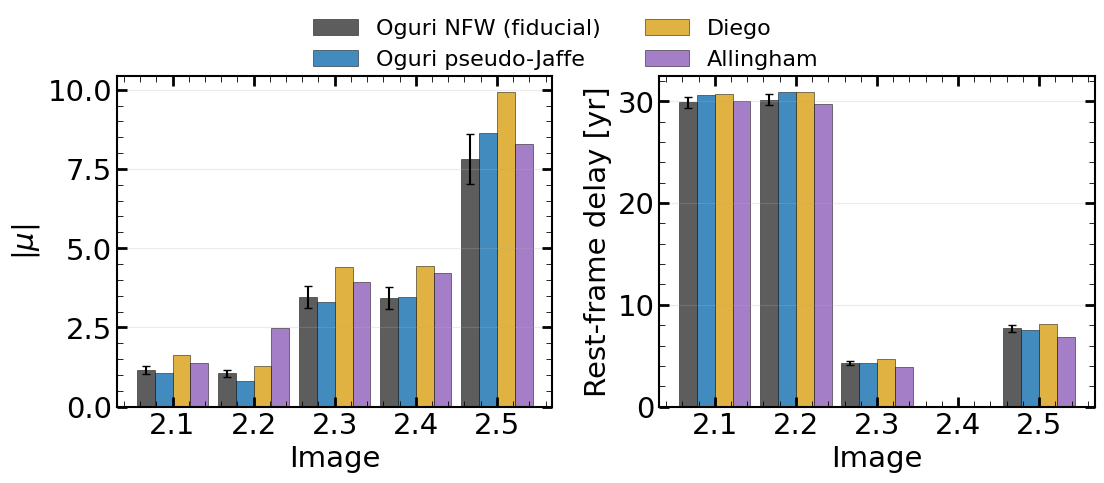

In [48]:
rx2_image_order = [f'2.{i}' for i in range(1, 6)]
rx2_x = np.arange(len(rx2_image_order))

oguri_nfw_rx2 = {image_id: {'mu': mu, 'dt_day': dt_day}
                 for image_id, x_arcsec, y_arcsec, mu, dt_day in OGURI_PROFILE_BLOCKS['Oguri NFW']['RX2']}
oguri_jaffe_rx2 = {image_id: {'mu': mu, 'dt_day': dt_day}
                   for image_id, x_arcsec, y_arcsec, mu, dt_day in OGURI_PROFILE_BLOCKS['Oguri Jaffe']['RX2']}

# Error bars from the Oguri/glafic fiducial summary.  This source maps directly to Oguri ids 10.1--10.5.
def oguri_nfw_error_for_rx2(image_id, param):
    img = image_id.split('.')[1]
    key = f'10.{img}'
    return symmetric_err(oguri[key][param])

oguri_nfw_xy_by_system = {
    'RX2': [(image_id, x_arcsec, y_arcsec)
            for image_id, x_arcsec, y_arcsec, mu, dt_day in OGURI_PROFILE_BLOCKS['Oguri NFW']['RX2']]
}
diego_rx2 = chema_values_at_xy(
    2,
    oguri_nfw_xy_by_system,
    model_label='Diego',
).set_index('image')
joseph_rx2 = joseph_outputs[joseph_outputs['system'] == 'RX2'].set_index('image')

rx2_plot_values = {
    'Oguri NFW (fiducial)': {
        'mu_abs': [abs(oguri_nfw_rx2[img]['mu']) for img in rx2_image_order],
        'mu_err': [max(oguri_nfw_error_for_rx2(img, 'mu'), MU_FLOOR_FRAC * abs(oguri_nfw_rx2[img]['mu'])) for img in rx2_image_order],
        'dt_rest_yr': [oguri_nfw_rx2[img]['dt_day'] / 365.25 / (1 + Z_SRC) for img in rx2_image_order],
        'dt_rest_err_yr': [oguri_nfw_error_for_rx2(img, 'dt') / 365.25 / (1 + Z_SRC) for img in rx2_image_order],
    },
    'Oguri pseudo-Jaffe': {
        'mu_abs': [abs(oguri_jaffe_rx2[img]['mu']) for img in rx2_image_order],
        'mu_err': [np.nan for _ in rx2_image_order],
        'dt_rest_yr': [oguri_jaffe_rx2[img]['dt_day'] / 365.25 / (1 + Z_SRC) for img in rx2_image_order],
        'dt_rest_err_yr': [np.nan for _ in rx2_image_order],
    },
    'Diego': {
        'mu_abs': [diego_rx2.loc[img, 'mu_abs'] for img in rx2_image_order],
        'mu_err': [np.nan for _ in rx2_image_order],
        'dt_rest_yr': [diego_rx2.loc[img, 'dt_rest_yr'] for img in rx2_image_order],
        'dt_rest_err_yr': [np.nan for _ in rx2_image_order],
    },
    JOSEPH_MODEL_NAME: {
        'mu_abs': [joseph_rx2.loc[img, 'mu_abs'] for img in rx2_image_order],
        'mu_err': [np.nan for _ in rx2_image_order],
        'dt_rest_yr': [joseph_rx2.loc[img, 'dt_rest_yr'] for img in rx2_image_order],
        'dt_rest_err_yr': [np.nan for _ in rx2_image_order],
    },
}

colors = {
    'Oguri NFW (fiducial)': '0.25',
    'Oguri pseudo-Jaffe': 'tab:blue',
    'Diego': 'goldenrod',
    JOSEPH_MODEL_NAME: 'tab:purple',
}

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))
# fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))
model_names = list(rx2_plot_values.keys())
width = 0.22
offsets = (np.arange(len(model_names)) - (len(model_names) - 1) / 2) * width
for ax, quantity, err_quantity, ylabel in [
    (axes[0], 'mu_abs', 'mu_err', r'$|\mu|$'),
    (axes[1], 'dt_rest_yr', 'dt_rest_err_yr', r'Rest-frame delay [yr]'),
]:
    for offset, model_name in zip(offsets, model_names):
        values = np.asarray(rx2_plot_values[model_name][quantity], dtype=float)
        yerr = np.asarray(rx2_plot_values[model_name][err_quantity], dtype=float)
        yerr = None if np.all(~np.isfinite(yerr)) else yerr
        ax.bar(
            rx2_x + offset,
            values,
            width=width,
            yerr=yerr,
            capsize=3 if yerr is not None else 0,
            color=colors[model_name],
            edgecolor='black',
            linewidth=0.4,
            alpha=0.85,
            label=model_name,
        )
    ax.set_xticks(rx2_x)
    ax.set_xticklabels(rx2_image_order)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Image')
    ax.grid(axis='y', alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.1),
    ncol=2,
    frameon=False,
    fontsize=16,
)

SOURCE_ID = 2
fig.tight_layout()
plt.savefig(OUTDIR / f'mu_dt_comparison_RX2.pdf', dpi=200, bbox_inches='tight')
plt.show()




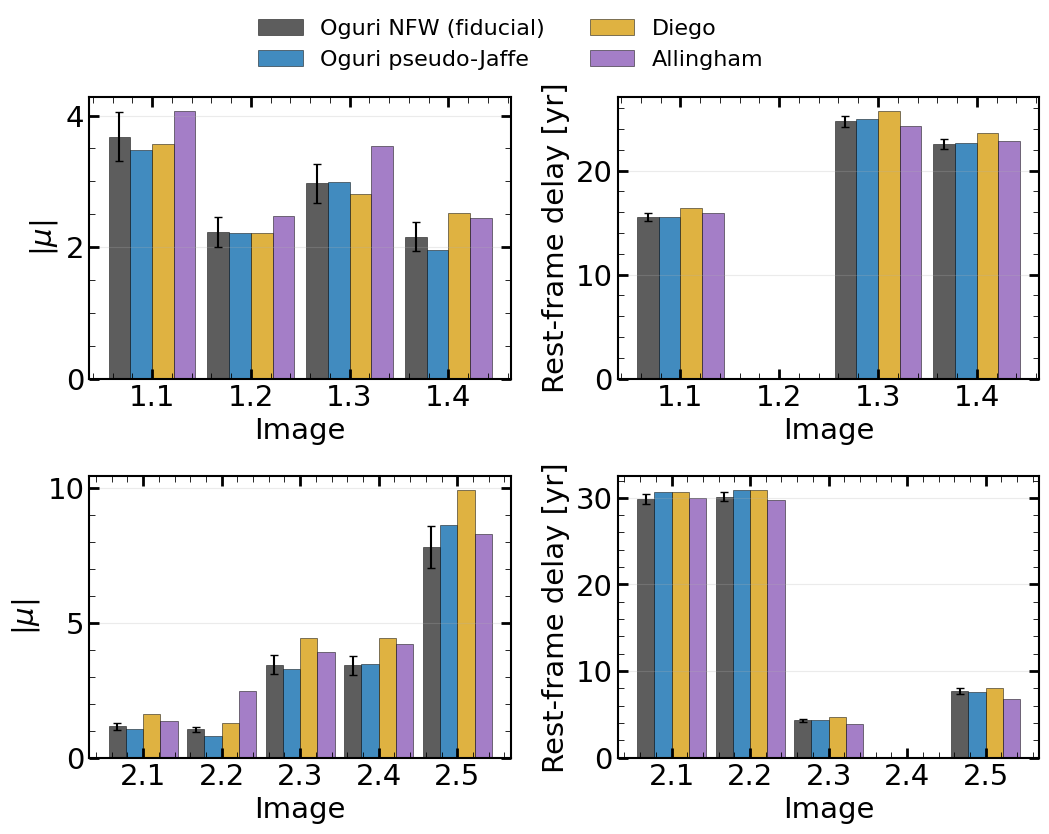

Wrote combined RX1/RX2 comparison figure: /Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/code/referee_Chema_lensmodel_outputs/mu_dt_comparison_RX1_RX2.pdf


In [49]:
# Combined RX1/RX2 magnification and time-delay comparison.
# This uses the already constructed RX1 `plot_values` and RX2 `rx2_plot_values`
# so that the combined figure is numerically identical to the separate panels.
combined_specs = [
    ('RX1', image_order, plot_values),
    ('RX2', rx2_image_order, rx2_plot_values),
]

fig, axes = plt.subplots(2, 2, figsize=(11.2, 8.4))
width = 0.22
model_names = list(plot_values.keys())
offsets = (np.arange(len(model_names)) - (len(model_names) - 1) / 2) * width

for row, (system_label, img_order, values_by_model) in enumerate(combined_specs):
    x_pos = np.arange(len(img_order))
    for col, (quantity, err_quantity, ylabel) in enumerate([
        ('mu_abs', 'mu_err', r'$|\mu|$'),
        ('dt_rest_yr', 'dt_rest_err_yr', r'Rest-frame delay [yr]'),
    ]):
        ax = axes[row, col]
        for offset, model_name in zip(offsets, model_names):
            values = np.asarray(values_by_model[model_name][quantity], dtype=float)
            yerr = np.asarray(values_by_model[model_name][err_quantity], dtype=float)
            yerr = None if np.all(~np.isfinite(yerr)) else yerr
            ax.bar(
                x_pos + offset,
                values,
                width=width,
                yerr=yerr,
                capsize=3 if yerr is not None else 0,
                color=colors[model_name],
                edgecolor='black',
                linewidth=0.4,
                alpha=0.85,
                label=model_name,
            )
        ax.set_xticks(x_pos)
        ax.set_xticklabels(img_order)
        ax.set_xlabel('Image')
        ax.set_ylabel(ylabel)
        ax.grid(axis='y', alpha=0.25)
        # ax.text(0.03, 0.92, system_label, transform=ax.transAxes,
        #         fontsize=15, fontweight='bold', va='top', ha='left')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
    fontsize=16,
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(OUTDIR / 'mu_dt_comparison_RX1_RX2.pdf', dpi=200, bbox_inches='tight')
plt.show()

print('Wrote combined RX1/RX2 comparison figure:', OUTDIR / 'mu_dt_comparison_RX1_RX2.pdf')
